# 02 — Exploratory Data Analysis (EDA)

## Objectif

L'objectif de ce notebook est d'explorer les données afin de mieux comprendre leur comportement statistique.

Nous analysons notamment les distributions, les variables, les groupes, les allocations ainsi que les premières relations avec la cible. Cette étape permet de formuler des hypothèses qui guideront les futures étapes de feature engineering et de modélisation.

## Imports

In [1]:
import sys 
from pathlib import Path

ROOT = Path.cwd().parent

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_loading import load_X_train, load_y_train, load_X_test, load_sample_submission

In [3]:
X_train, y_train, X_test, sample_submission = load_X_train(), load_y_train(), load_X_test(), load_sample_submission()

## Analyse de notre target

In [4]:
y_train.head()

,ROW_ID,target
0,0,0.009210
1,1,0.000405
2,2,0.005967
3,3,-0.000542
4,4,-0.002579


### Distribution des rendements de notre allocation

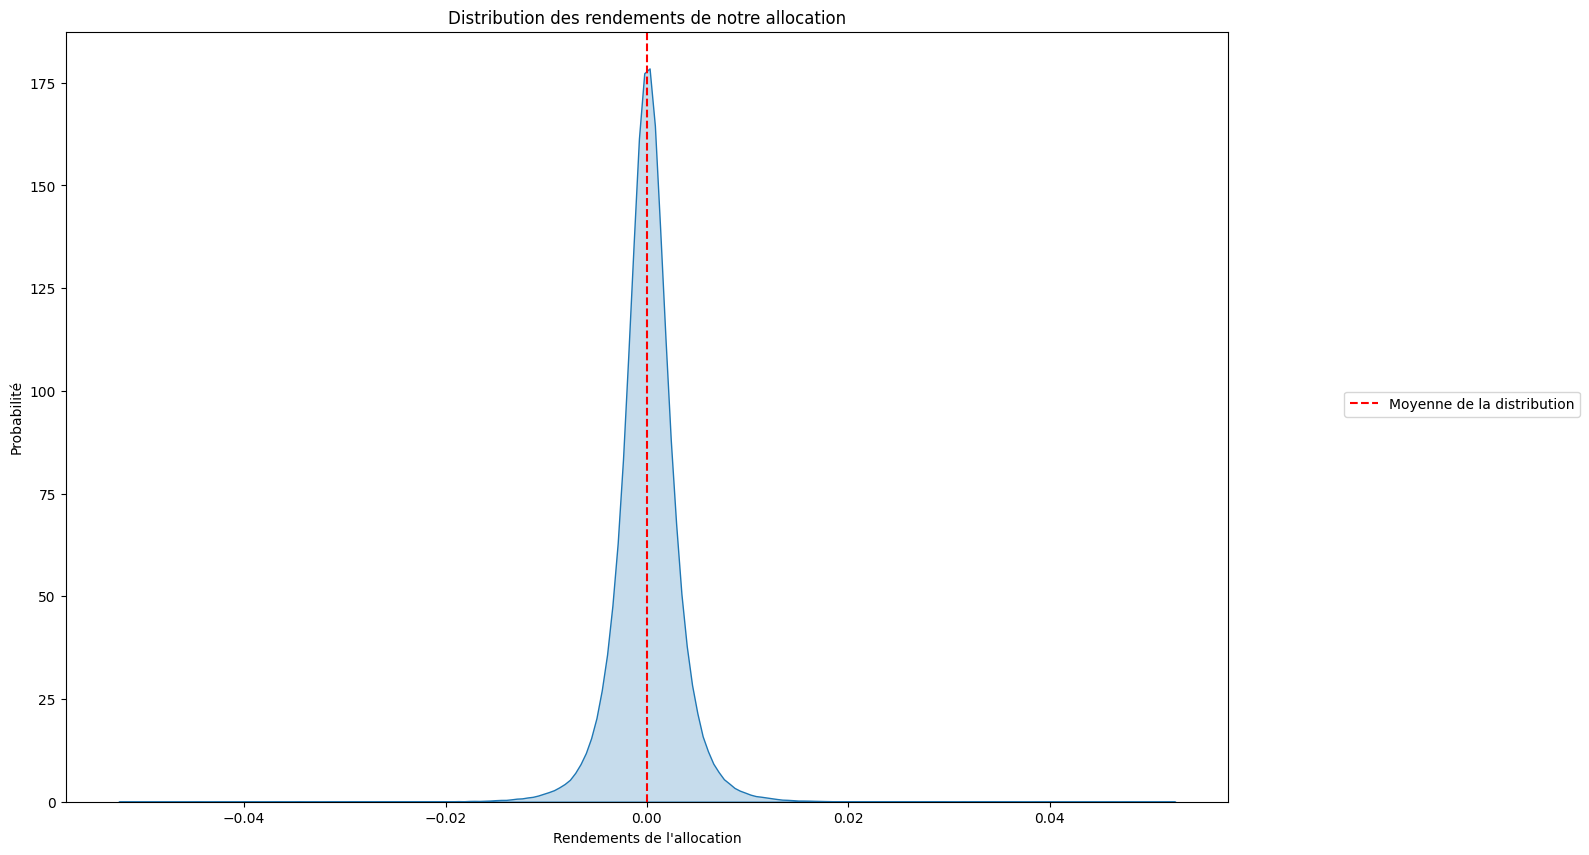

In [5]:
plt.figure(figsize=(15,10))
sns.kdeplot(data=y_train["target"],fill=True)
plt.axvline(x=y_train["target"].mean(),label="Moyenne de la distribution",c="r",ls="--")
plt.xlabel("Rendements de l'allocation")
plt.ylabel("Probabilité")
plt.title("Distribution des rendements de notre allocation")
plt.legend(loc=(1.1,0.5));

- On remarque la moyenne de nos rendements est proche de 0 et distribution est centrée autour de 0
- On remarque aussi la présence de queues épaisses

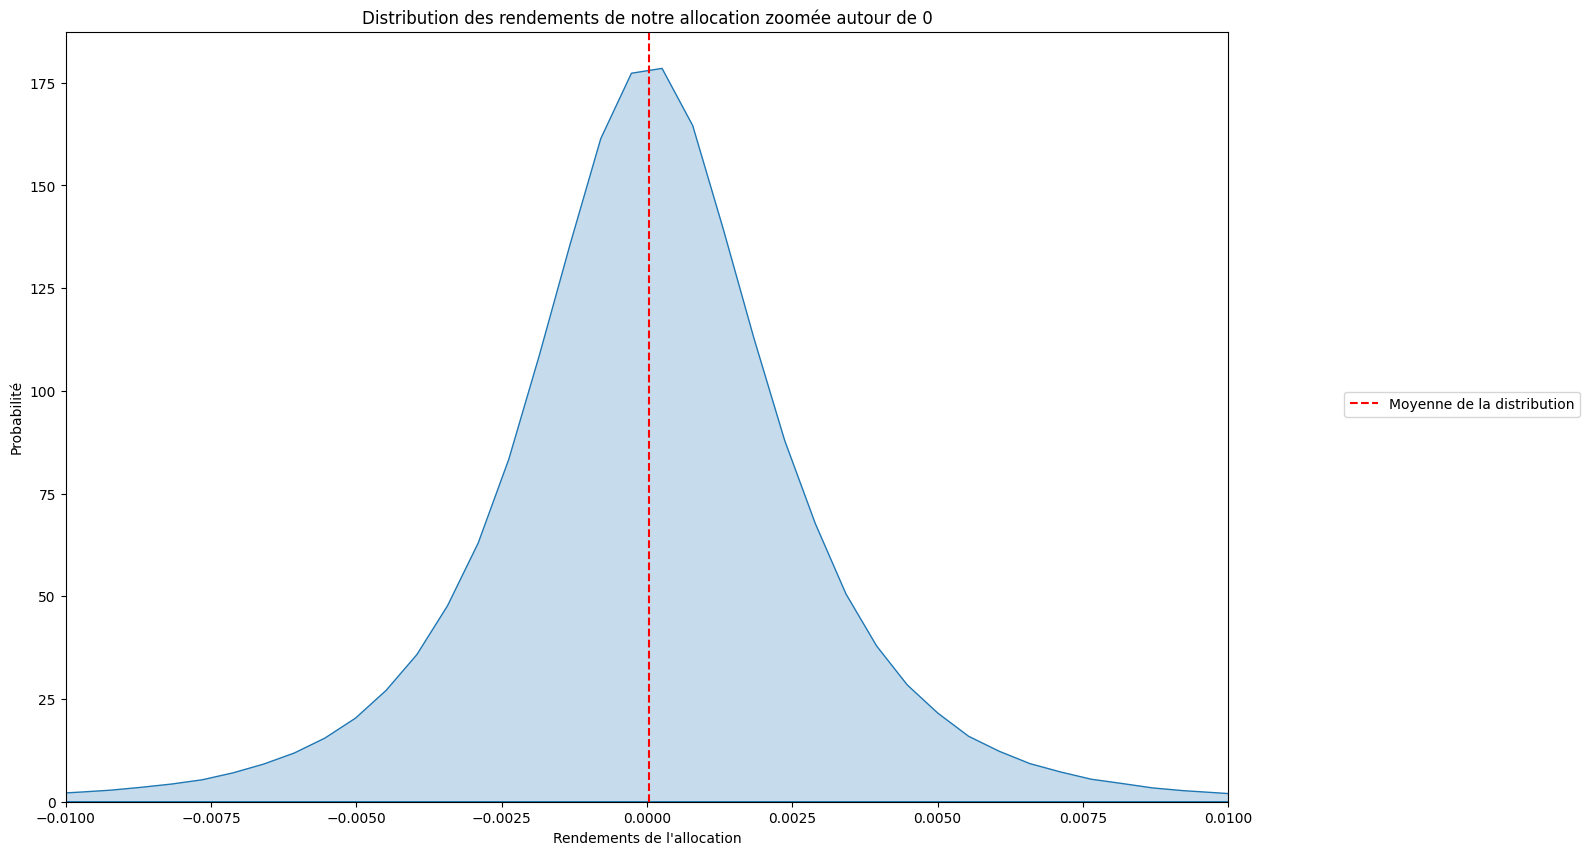

In [6]:
plt.figure(figsize=(15,10))
sns.kdeplot(data=y_train["target"],fill=True)
plt.axvline(x=y_train["target"].mean(),label="Moyenne de la distribution",c="r",ls="--")
plt.xlim(-0.01,0.01)
plt.xlabel("Rendements de l'allocation")
plt.ylabel("Probabilité")
plt.title("Distribution des rendements de notre allocation zoomée autour de 0")
plt.legend(loc=(1.1,0.5));

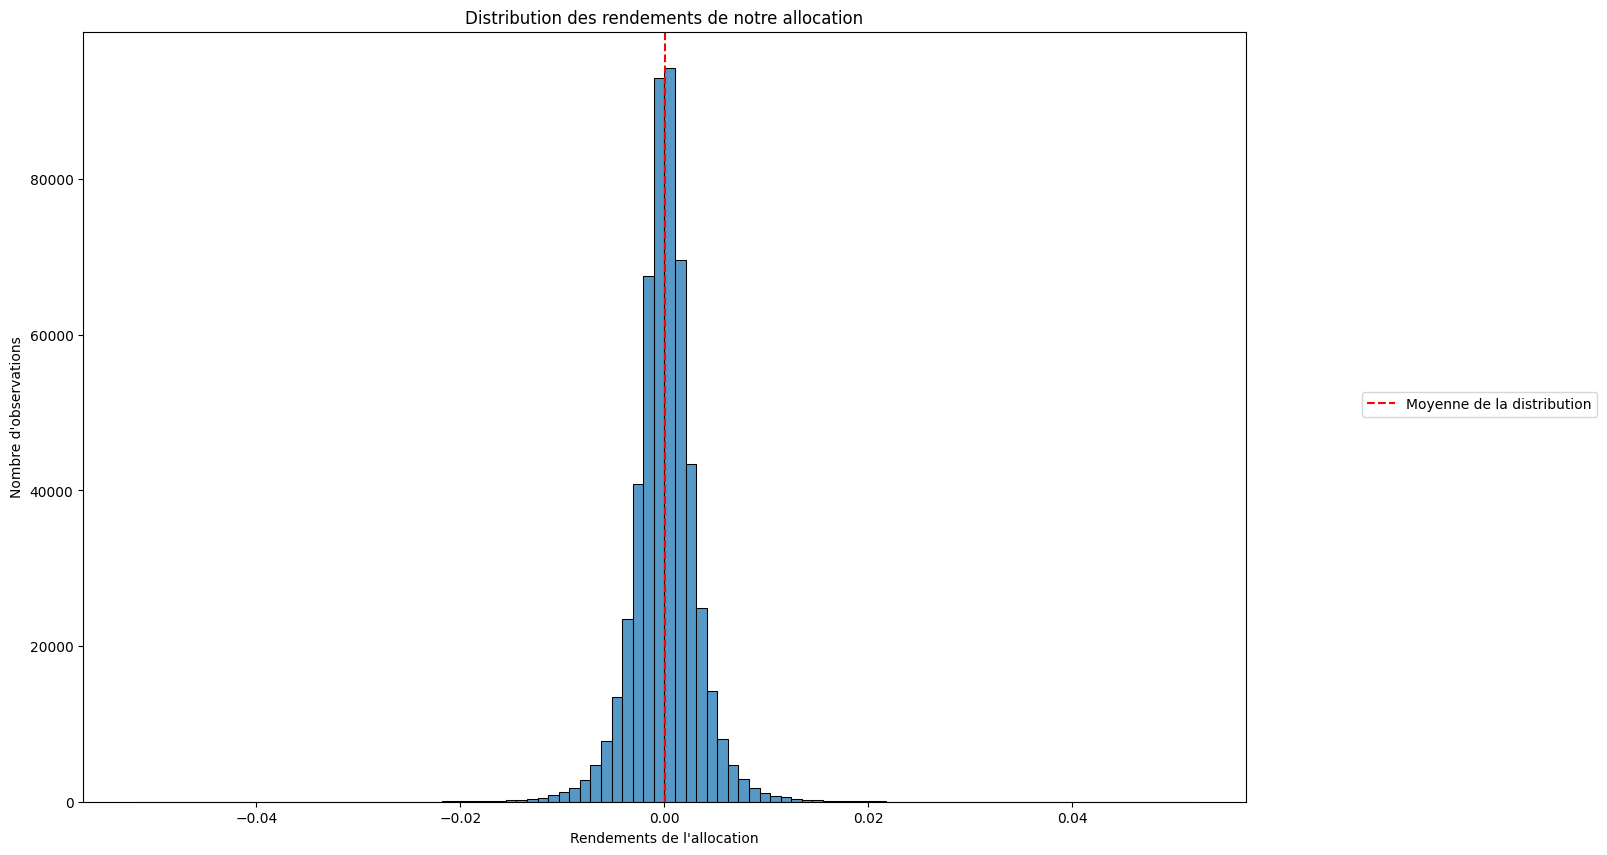

In [7]:
plt.figure(figsize=(15,10))
sns.histplot(data=y_train["target"],bins=100)
plt.axvline(x=y_train["target"].mean(),label="Moyenne de la distribution",c="r",ls="--")
plt.xlabel("Rendements de l'allocation")
plt.ylabel("Nombre d'observations")
plt.title("Distribution des rendements de notre allocation")
plt.legend(loc=(1.1,0.5));

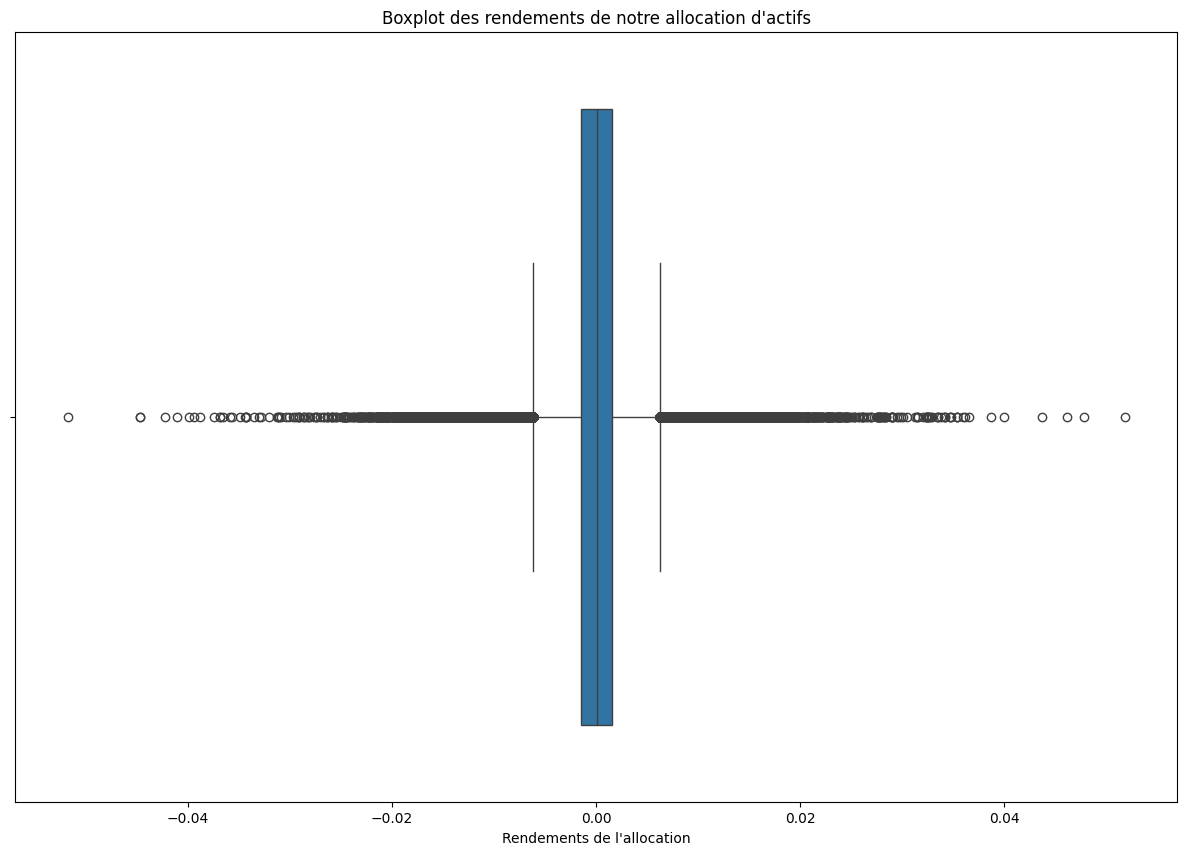

In [8]:
plt.figure(figsize=(15,10))
sns.boxplot(data=y_train,x="target")
plt.xlabel("Rendements de l'allocation")
plt.title("Boxplot des rendements de notre allocation d'actifs");

Nous remarquons la présence de nombreuse valeurs extrêmes.

### Barplot des classes

In [9]:
y_train_copy = y_train.copy()
y_train_copy["classe"] = np.where(y_train["target"] > 0,1,0)

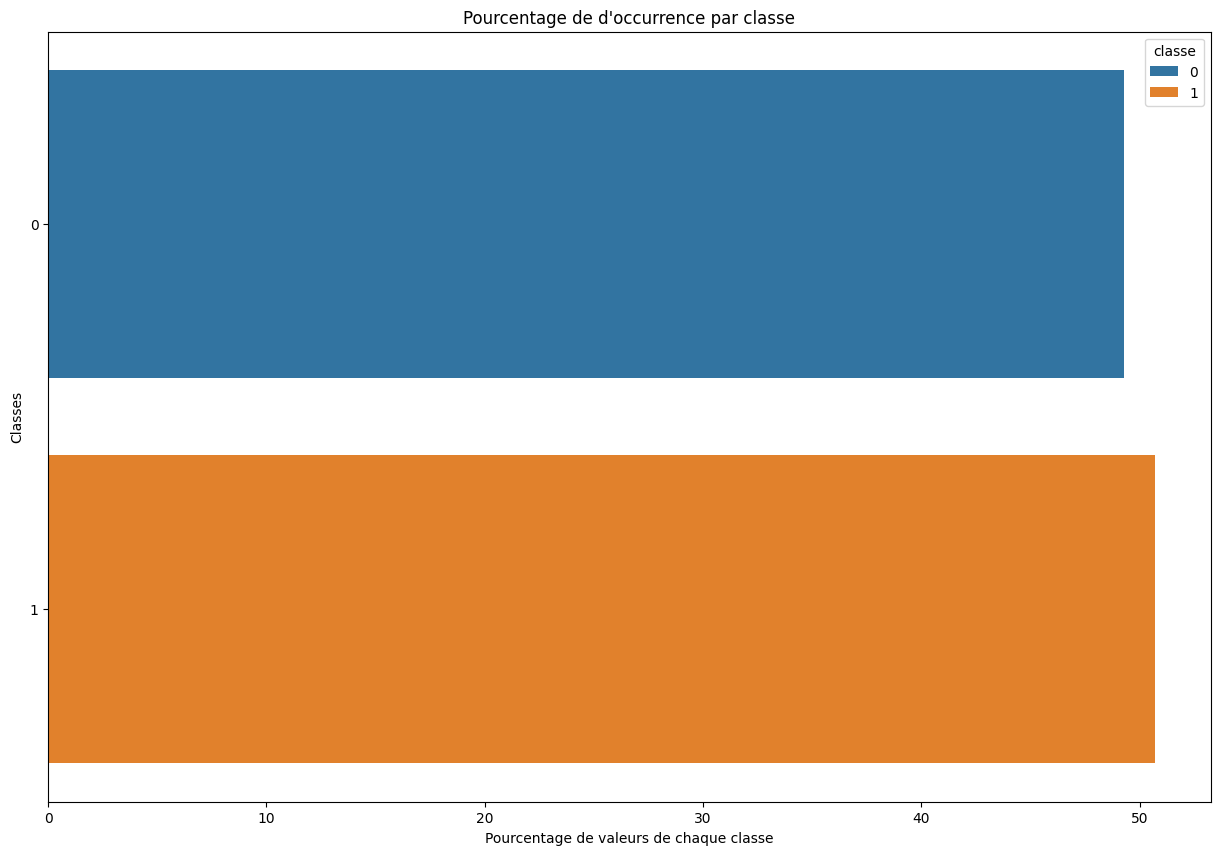

In [10]:
plt.figure(figsize=(15,10))
sns.countplot(data=y_train_copy,y="classe",hue="classe",stat="percent")
plt.xlabel("Pourcentage de valeurs de chaque classe")
plt.ylabel("Classes")
plt.title("Pourcentage de d'occurrence par classe");

On remarque les classes sont assez équilibrés, environ 50% d'occurrence pour chaque classe

Trouvons les proportions exactes

In [11]:
percent_0 = (len(y_train_copy[y_train_copy["classe"] == 0]) / len(y_train_copy)) * 100
percent_1 = (len(y_train_copy[y_train_copy["classe"] == 1]) / len(y_train_copy)) * 100
print(f"La classe négative représente {percent_0:.3}% des observations.")
print(f"La classe positive représente {percent_1:.3}% des observations.")

La classe négative représente 49.3% des observations.
La classe positive représente 50.7% des observations.


**Interpretation :** 
- Une baseline naïve qui prédit toujours la classe majoritaire aurait environ 50.7% d'accuracy.
- Donc un futur modèle devra faire clairement mieux que 50.7 % pour apporter un vrai signal prédictif.

Affichons les statistiques descriptives de la target

In [12]:
y_train_copy.describe()["target"]

count    527073.000000
mean          0.000035
std           0.003106
min          -0.051809
25%          -0.001517
50%           0.000041
75%           0.001600
max           0.051803
Name: target, dtype: float64

In [13]:
y_train_copy["classe"].value_counts()

classe
1    267323
0    259750
Name: count, dtype: int64

## Analyse temporelle avec TS

In [14]:
X_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 527073 entries, 0 to 527072
Data columns (total 45 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ROW_ID                 527073 non-null  int64  
 1   TS                     527073 non-null  str    
 2   ALLOCATION             527073 non-null  str    
 3   RET_20                 527015 non-null  float64
 4   RET_19                 527023 non-null  float64
 5   RET_18                 527031 non-null  float64
 6   RET_17                 527039 non-null  float64
 7   RET_16                 527047 non-null  float64
 8   RET_15                 527055 non-null  float64
 9   RET_14                 527060 non-null  float64
 10  RET_13                 527064 non-null  float64
 11  RET_12                 527067 non-null  float64
 12  RET_11                 527069 non-null  float64
 13  RET_10                 527071 non-null  float64
 14  RET_9                  527073 non-null  float64

In [15]:
X_train["TS"].unique()

<StringArray>
['DATE_0001', 'DATE_0002', 'DATE_0003', 'DATE_0004', 'DATE_0005', 'DATE_0006',
 'DATE_0007', 'DATE_0008', 'DATE_0009', 'DATE_0010',
 ...
 'DATE_2513', 'DATE_2514', 'DATE_2515', 'DATE_2516', 'DATE_2517', 'DATE_2518',
 'DATE_2519', 'DATE_2520', 'DATE_2521', 'DATE_2522']
Length: 2522, dtype: str

On remarque qu'il existe environ 2522 dates différentes dans notre ensemble de données

In [16]:
X_train["TS"].value_counts()

TS
DATE_0001    276
DATE_0002    276
DATE_0005    276
DATE_0007    276
DATE_0010    276
            ... 
DATE_2466     65
DATE_2473     65
DATE_2500     65
DATE_2503     65
DATE_2520     65
Name: count, Length: 2522, dtype: int64

Nous remarquons bien que certaines dates sont plus représentées que d'autres.

In [17]:
X_test['TS'].value_counts()

TS
DATE_2526    278
DATE_2527    278
DATE_2528    278
DATE_2529    278
DATE_2530    278
            ... 
DATE_2622    208
DATE_2558    206
DATE_2560    206
DATE_2524    140
DATE_2602     70
Name: count, Length: 120, dtype: int64

In [18]:
X_test['TS'].unique()

<StringArray>
['DATE_2523', 'DATE_2524', 'DATE_2525', 'DATE_2526', 'DATE_2527', 'DATE_2528',
 'DATE_2529', 'DATE_2530', 'DATE_2531', 'DATE_2532',
 ...
 'DATE_2633', 'DATE_2634', 'DATE_2635', 'DATE_2636', 'DATE_2637', 'DATE_2638',
 'DATE_2639', 'DATE_2640', 'DATE_2641', 'DATE_2642']
Length: 120, dtype: str

D'après les données qu'on a il semblerait que le test soit bien situé après le train ce qui nous pousse à probablement utiliser une validation temporelle, par exemple entraîner sur les anciennes date et valider sur les dates les plus récentes.

Faisons un resume numerique du nombre de lignes par date

In [19]:
ts_count = pd.DataFrame(X_train["TS"].value_counts(sort=False))
ts_count.columns = ["occurrence_par_date"]
ts_count.describe()

,occurrence_par_date
count,2522.000000
mean,208.990087
std,81.903327
min,65.000000
25%,140.000000
50%,276.000000
75%,276.000000
max,276.000000


Le nombre d’observations par date varie fortement, de 65 à 276. La moyenne est d’environ 208 observations, mais la médiane est à 276, ce qui indique qu’une grande partie des dates contient le maximum d’observations observé.

In [20]:
ts_count.index.unique()

Index(['DATE_0001', 'DATE_0002', 'DATE_0003', 'DATE_0004', 'DATE_0005',
       'DATE_0006', 'DATE_0007', 'DATE_0008', 'DATE_0009', 'DATE_0010',
       ...
       'DATE_2513', 'DATE_2514', 'DATE_2515', 'DATE_2516', 'DATE_2517',
       'DATE_2518', 'DATE_2519', 'DATE_2520', 'DATE_2521', 'DATE_2522'],
      dtype='str', name='TS', length=2522)

Les dates étant encodées avec quatre chiffres, l’ordre lexicographique correspond à l’ordre chronologique.

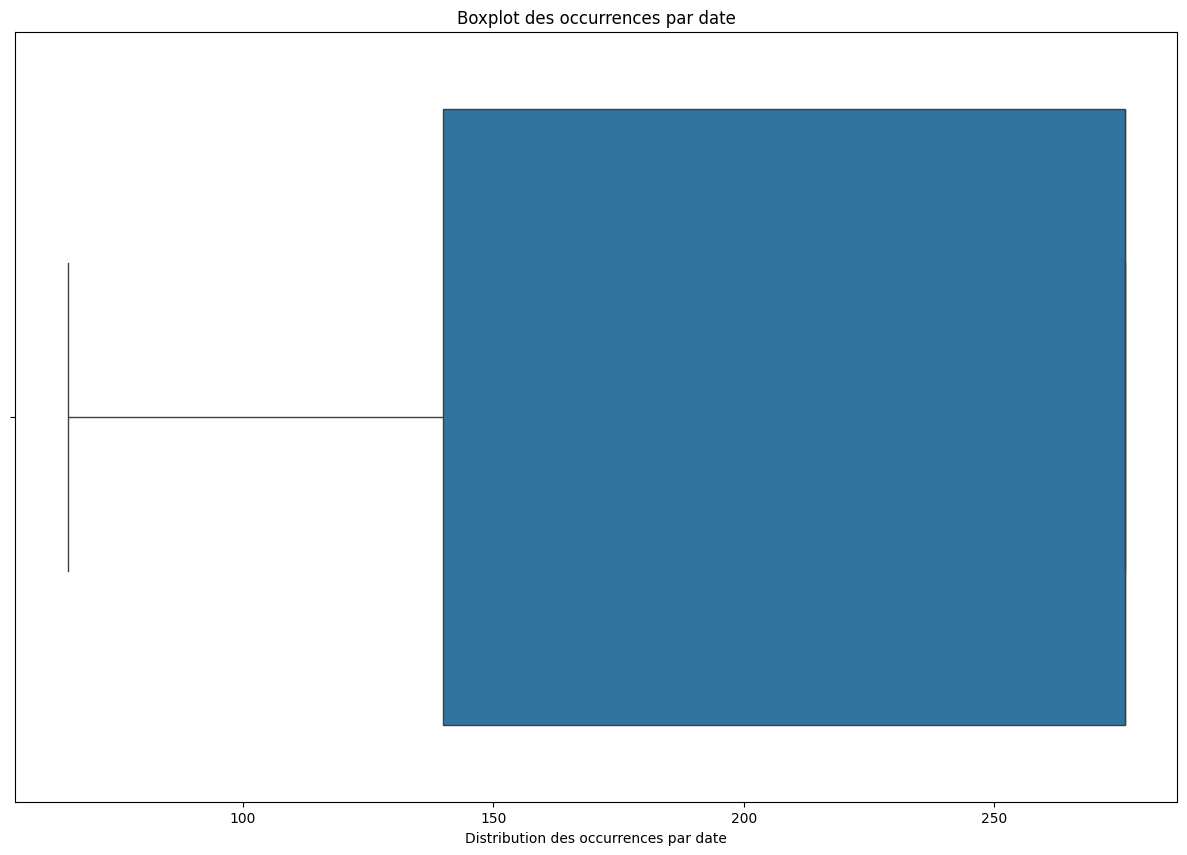

In [21]:
plt.figure(figsize=(15,10))
sns.boxplot(data=ts_count,x="occurrence_par_date")
plt.xlabel("Distribution des occurrences par date")
plt.title("Boxplot des occurrences par date");

Le nombre d’observations par date varie fortement, de 65 à 276. La médiane et le troisième quartile sont à 276, ce qui signifie qu’une grande partie des dates contient le maximum d’observations observé dans le train.

In [22]:
ts_count

,occurrence_par_date
TS,
DATE_0001,276
DATE_0002,276
DATE_0003,69
DATE_0004,204
DATE_0005,276
...,...
DATE_2518,276
DATE_2519,69
DATE_2520,65


**Trouvons la proportion de targets positifs par date**

In [23]:
X_train

,ROW_ID,TS,ALLOCATION,RET_20,RET_19,RET_18,RET_17,RET_16,RET_15,RET_14,...,SIGNED_VOLUME_8,SIGNED_VOLUME_7,SIGNED_VOLUME_6,SIGNED_VOLUME_5,SIGNED_VOLUME_4,SIGNED_VOLUME_3,SIGNED_VOLUME_2,SIGNED_VOLUME_1,MEDIAN_DAILY_TURNOVER,GROUP
0,0,DATE_0001,ALLOCATION_01,-0.018192,-0.000306,-0.006881,-0.002393,0.000507,-0.001270,-0.002539,...,0.818730,0.941014,0.714129,-0.323847,0.525097,0.363601,-0.219328,NaN,0.096905,1
1,1,DATE_0001,ALLOCATION_02,-0.006394,-0.001059,0.001565,0.000033,0.002829,0.001725,0.000875,...,-1.390336,-0.651784,-0.896826,-0.636931,-1.074450,-0.748884,-0.718912,NaN,0.009974,4
2,2,DATE_0001,ALLOCATION_03,-0.016587,-0.004517,-0.005306,0.004314,0.006471,-0.005868,-0.005030,...,0.961318,0.452482,1.588321,0.790039,1.394445,0.493521,0.268094,NaN,0.044186,1
3,3,DATE_0001,ALLOCATION_04,-0.005344,0.002790,0.006937,-0.004246,-0.005051,-0.000330,-0.000117,...,-0.483377,-0.565114,-0.631710,-0.663300,-1.615905,-0.959046,-0.478789,NaN,0.001150,2
4,4,DATE_0001,ALLOCATION_05,-0.010506,-0.005491,0.007752,-0.012299,0.002191,0.003282,0.000495,...,0.268005,0.757707,1.524626,1.565541,1.563963,1.063209,0.921333,NaN,NaN,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
527068,527068,DATE_2522,ALLOCATION_95,-0.000550,0.001751,0.002035,0.005264,0.003387,0.001825,-0.003642,...,1.184249,1.154274,0.925998,1.154043,1.007770,0.801765,0.131619,NaN,0.000478,4
527069,527069,DATE_2522,ALLOCATION_96,0.003501,-0.004601,-0.001739,-0.000052,0.003670,0.002518,0.006307,...,0.673371,0.481303,0.702007,1.006299,1.256455,1.174986,1.539785,NaN,0.003128,3
527070,527070,DATE_2522,ALLOCATION_97,0.005201,0.000580,-0.001607,-0.002955,0.000450,0.004747,0.004622,...,0.775938,0.845494,0.799003,1.042934,1.260539,1.450301,1.492719,NaN,0.021932,3
527071,527071,DATE_2522,ALLOCATION_98,-0.000110,0.000371,0.000852,0.000938,0.000887,-0.001882,0.000278,...,-0.972334,-0.529001,-1.457916,-0.062793,-1.714044,-2.124111,-5.510514,NaN,0.026245,4


In [24]:
targets_by_date = X_train.merge(y_train,how='inner',left_on="ROW_ID",right_on='ROW_ID')[["TS","target"]]

In [25]:
targets_by_date.info()

<class 'pandas.DataFrame'>
RangeIndex: 527073 entries, 0 to 527072
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   TS      527073 non-null  str    
 1   target  527073 non-null  float64
dtypes: float64(1), str(1)
memory usage: 8.0 MB


In [26]:
targets_by_date.head()

,TS,target
0,DATE_0001,0.009210
1,DATE_0001,0.000405
2,DATE_0001,0.005967
3,DATE_0001,-0.000542
4,DATE_0001,-0.002579


In [27]:
targets_by_date["class"] = np.where(targets_by_date["target"]>0,1,0)

In [28]:
targets_by_date.head()

,TS,target,class
0,DATE_0001,0.009210,1
1,DATE_0001,0.000405,1
2,DATE_0001,0.005967,1
3,DATE_0001,-0.000542,0
4,DATE_0001,-0.002579,0


In [29]:
targets_by_date = targets_by_date.groupby("TS").mean()["class"]

In [30]:
targets_by_date.head()

TS
DATE_0001    0.648551
DATE_0002    0.597826
DATE_0003    0.478261
DATE_0004    0.367647
DATE_0005    0.518116
Name: class, dtype: float64

In [31]:
targets_by_date.describe()

count    2522.000000
mean        0.506849
std         0.095972
min         0.153846
25%         0.442029
50%         0.507246
75%         0.568841
max         0.900000
Name: class, dtype: float64

- en moyenne, les dates sont autour de 50,7 % de classe positive ;
- la médiane est aussi proche de 50 % ;
- mais certaines dates sont très négatives, avec seulement 15,4 % de classes positives ;
- certaines dates sont très positives, jusqu’à 90 % de classes positives ;
- donc la date peut refléter un contexte de marché très différent.

Même si la target est globalement équilibrée, certaines dates sont très déséquilibrées.

Le train contient les dates de DATE_0001 à DATE_2522, et le test commence juste après, à partir de DATE_2523. Le test correspond donc à une période future par rapport au train.

On observe aussi que toutes les dates n’ont pas le même nombre d’allocations, et que certaines dates sont beaucoup plus positives ou négatives que d’autres.

Donc, pour évaluer correctement le modèle, il vaut mieux utiliser une validation temporelle : entraîner sur les anciennes dates et valider sur les dates les plus récentes, plutôt que de mélanger les dates au hasard.

## Analyse des rendements RET

Analysons les distributions de certains rendements

In [32]:
X_train.columns

Index(['ROW_ID', 'TS', 'ALLOCATION', 'RET_20', 'RET_19', 'RET_18', 'RET_17',
       'RET_16', 'RET_15', 'RET_14', 'RET_13', 'RET_12', 'RET_11', 'RET_10',
       'RET_9', 'RET_8', 'RET_7', 'RET_6', 'RET_5', 'RET_4', 'RET_3', 'RET_2',
       'RET_1', 'SIGNED_VOLUME_20', 'SIGNED_VOLUME_19', 'SIGNED_VOLUME_18',
       'SIGNED_VOLUME_17', 'SIGNED_VOLUME_16', 'SIGNED_VOLUME_15',
       'SIGNED_VOLUME_14', 'SIGNED_VOLUME_13', 'SIGNED_VOLUME_12',
       'SIGNED_VOLUME_11', 'SIGNED_VOLUME_10', 'SIGNED_VOLUME_9',
       'SIGNED_VOLUME_8', 'SIGNED_VOLUME_7', 'SIGNED_VOLUME_6',
       'SIGNED_VOLUME_5', 'SIGNED_VOLUME_4', 'SIGNED_VOLUME_3',
       'SIGNED_VOLUME_2', 'SIGNED_VOLUME_1', 'MEDIAN_DAILY_TURNOVER', 'GROUP'],
      dtype='str')

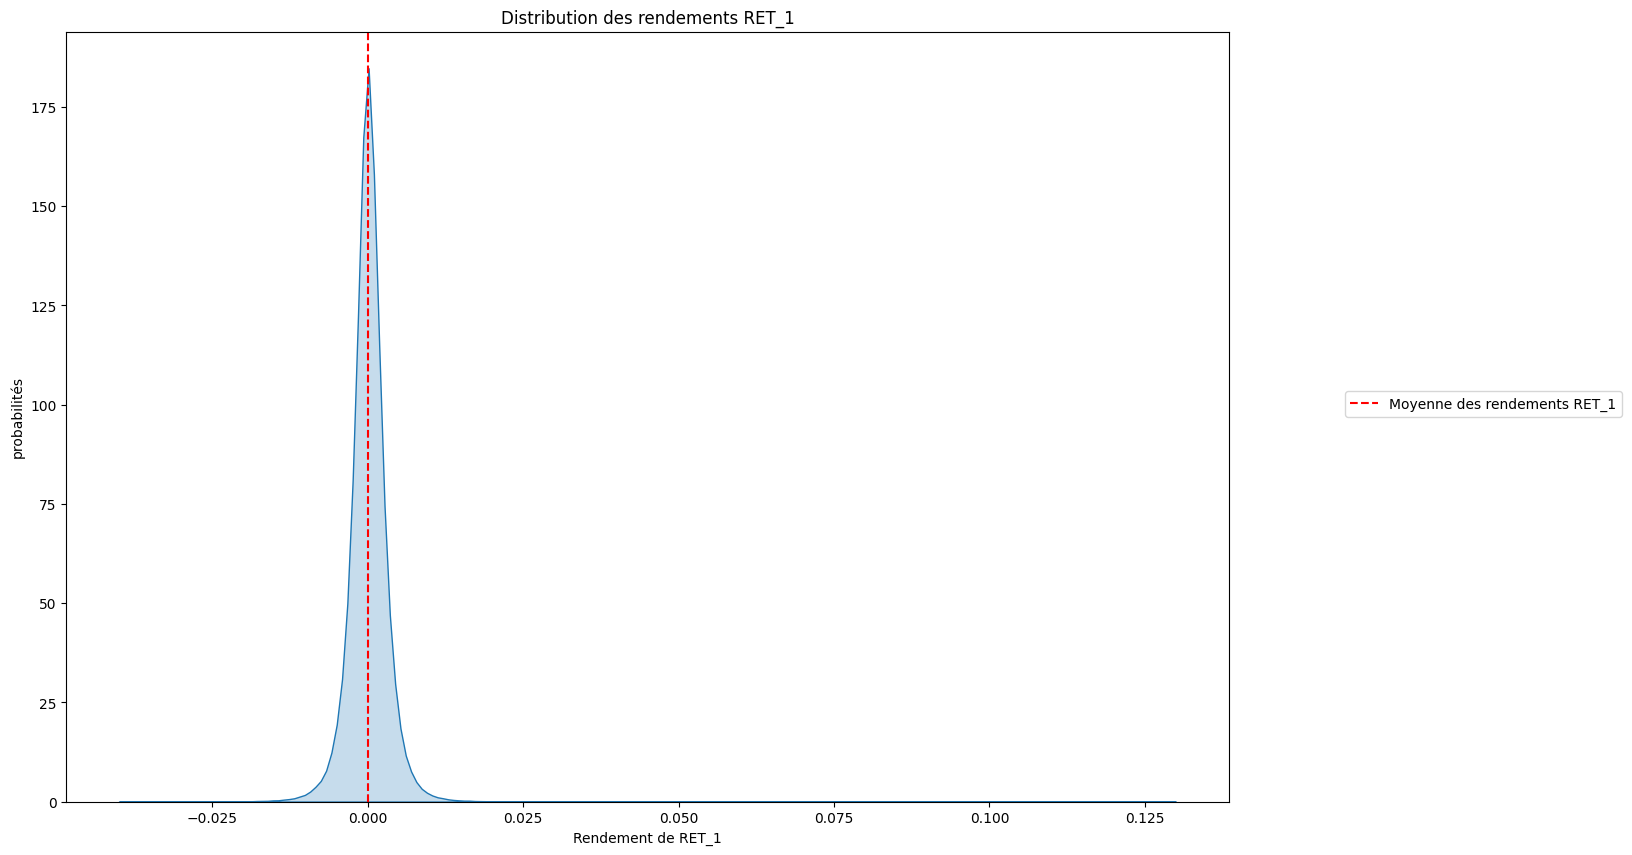

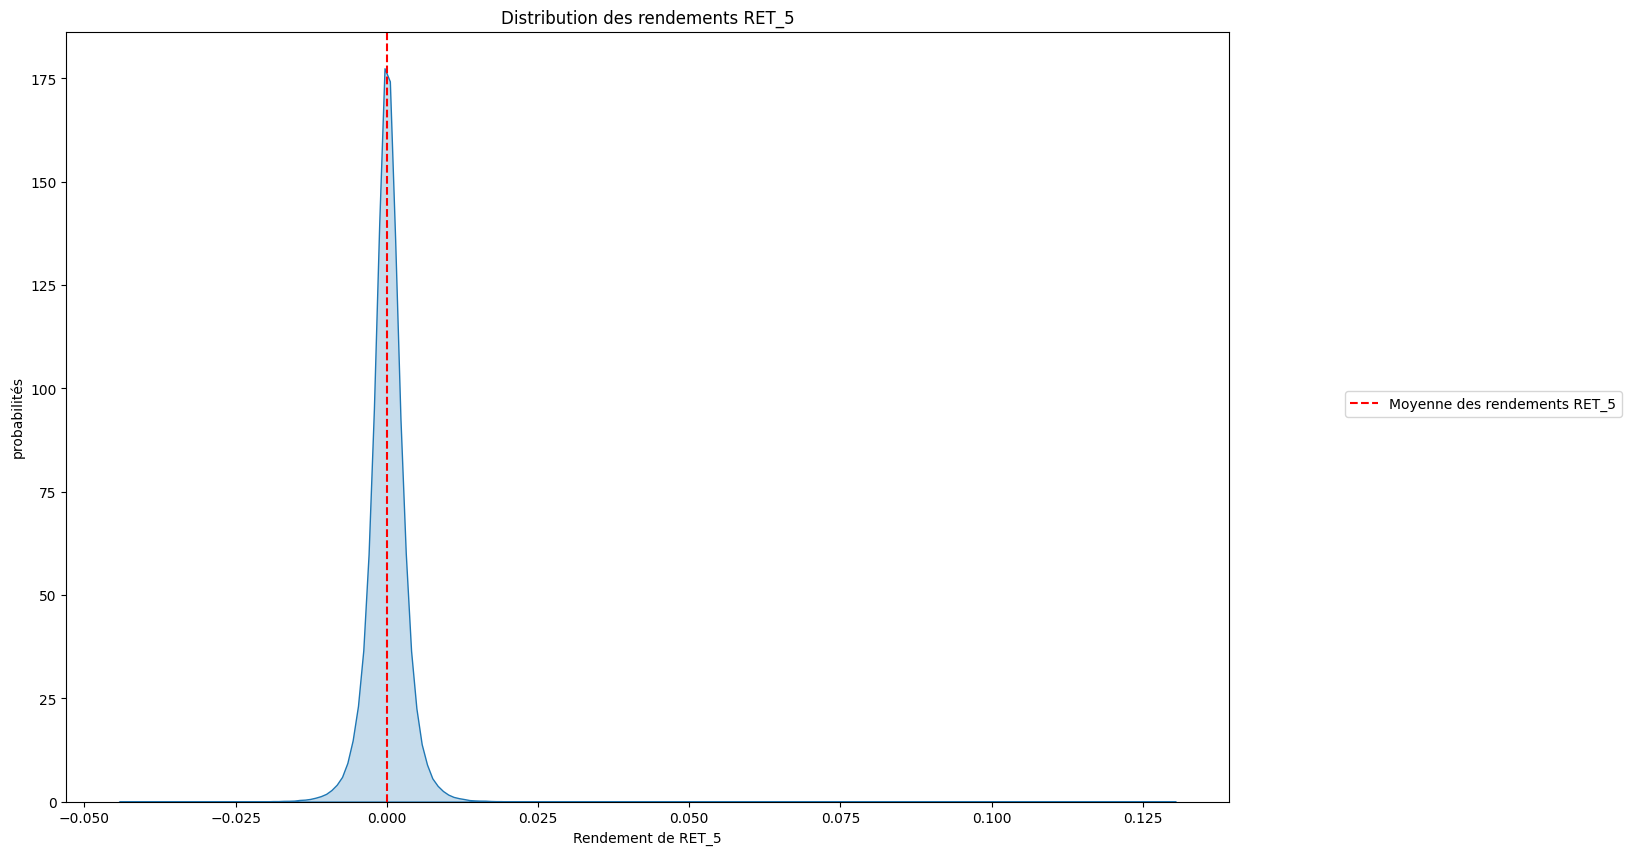

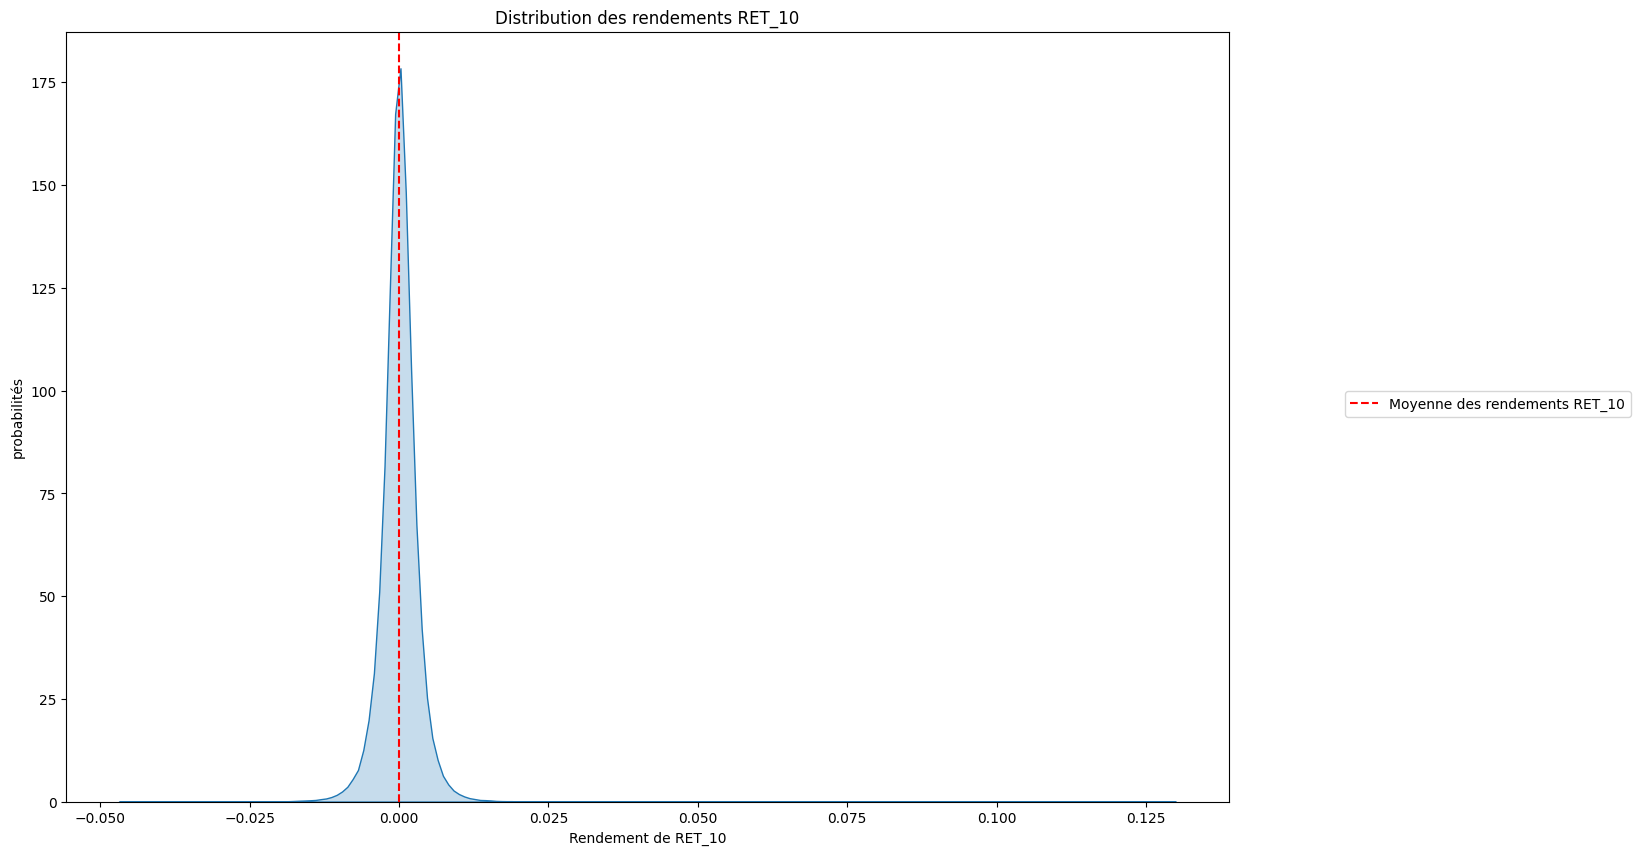

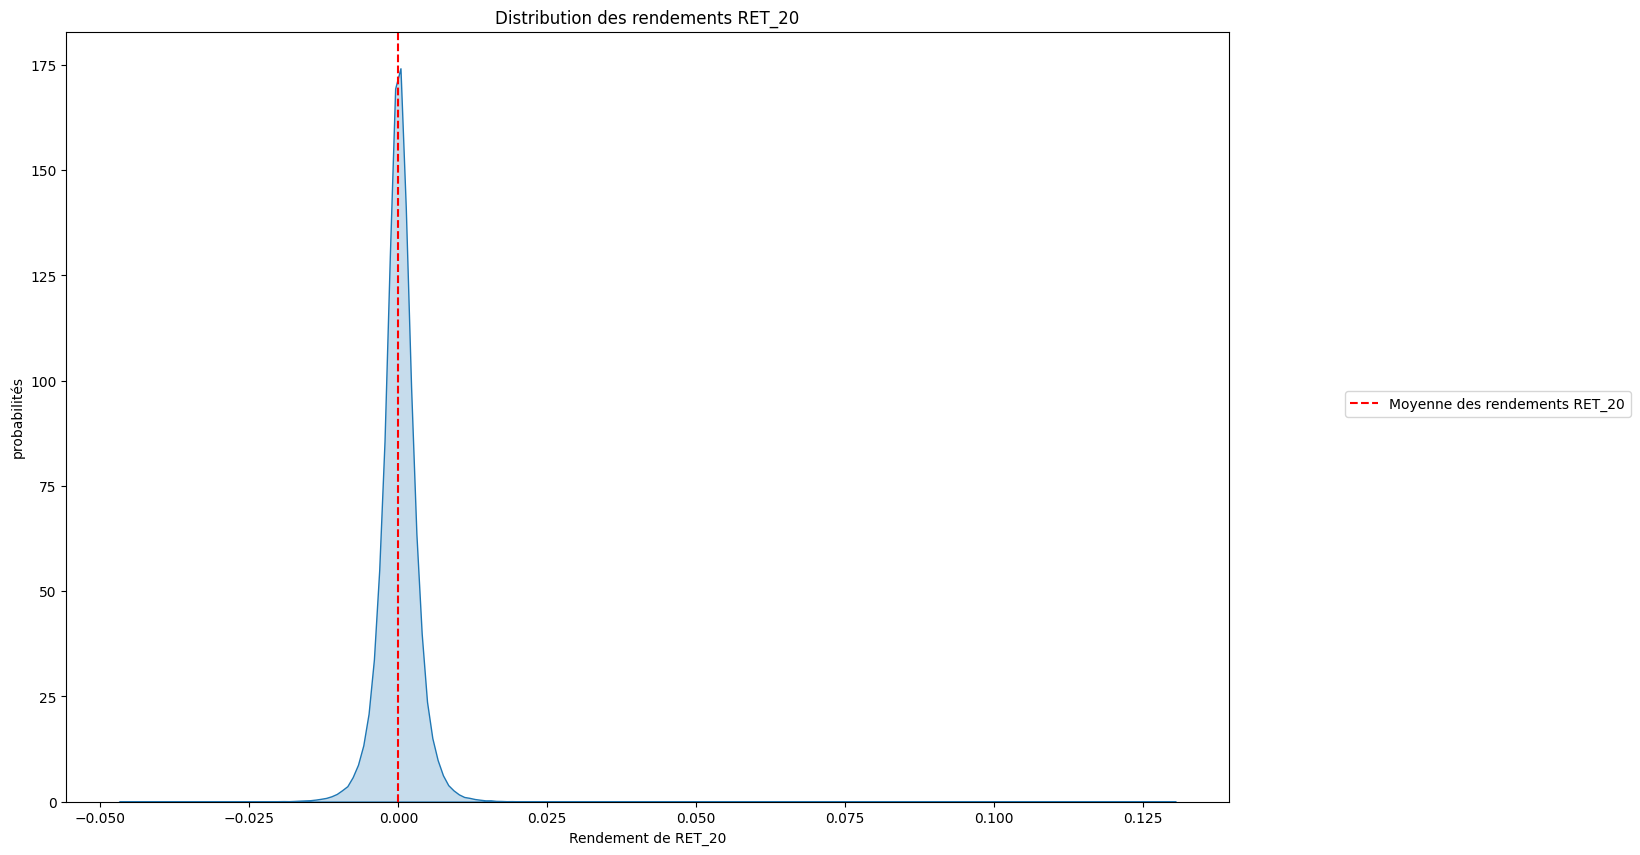

In [33]:
list_ret = ['RET_1','RET_5','RET_10','RET_20']
for ret in list_ret:
    plt.figure(figsize=(15,10))
    sns.kdeplot(data=X_train,x=ret,fill=True)
    plt.axvline(x=X_train[ret].mean(),label=f"Moyenne des rendements {ret}",ls='--',c='r')
    plt.xlabel(f"Rendement de {ret}")
    plt.ylabel("probabilités")
    plt.title(f"Distribution des rendements {ret}")
    plt.legend(loc=(1.1,0.5));

Boxplot des rendements RET_1, RET_5, RET_10, RET_20

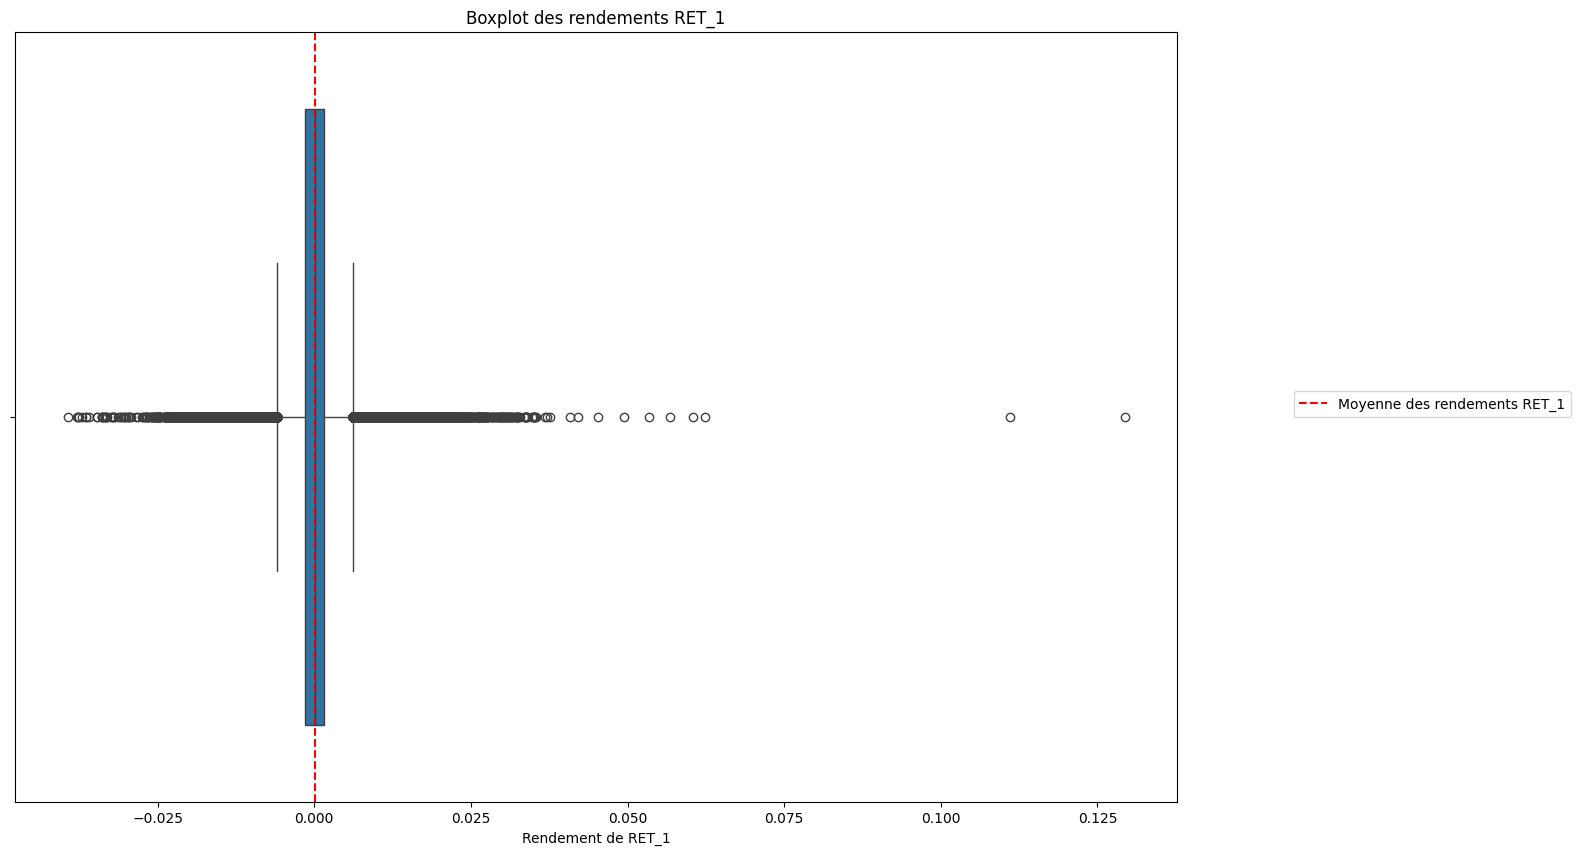

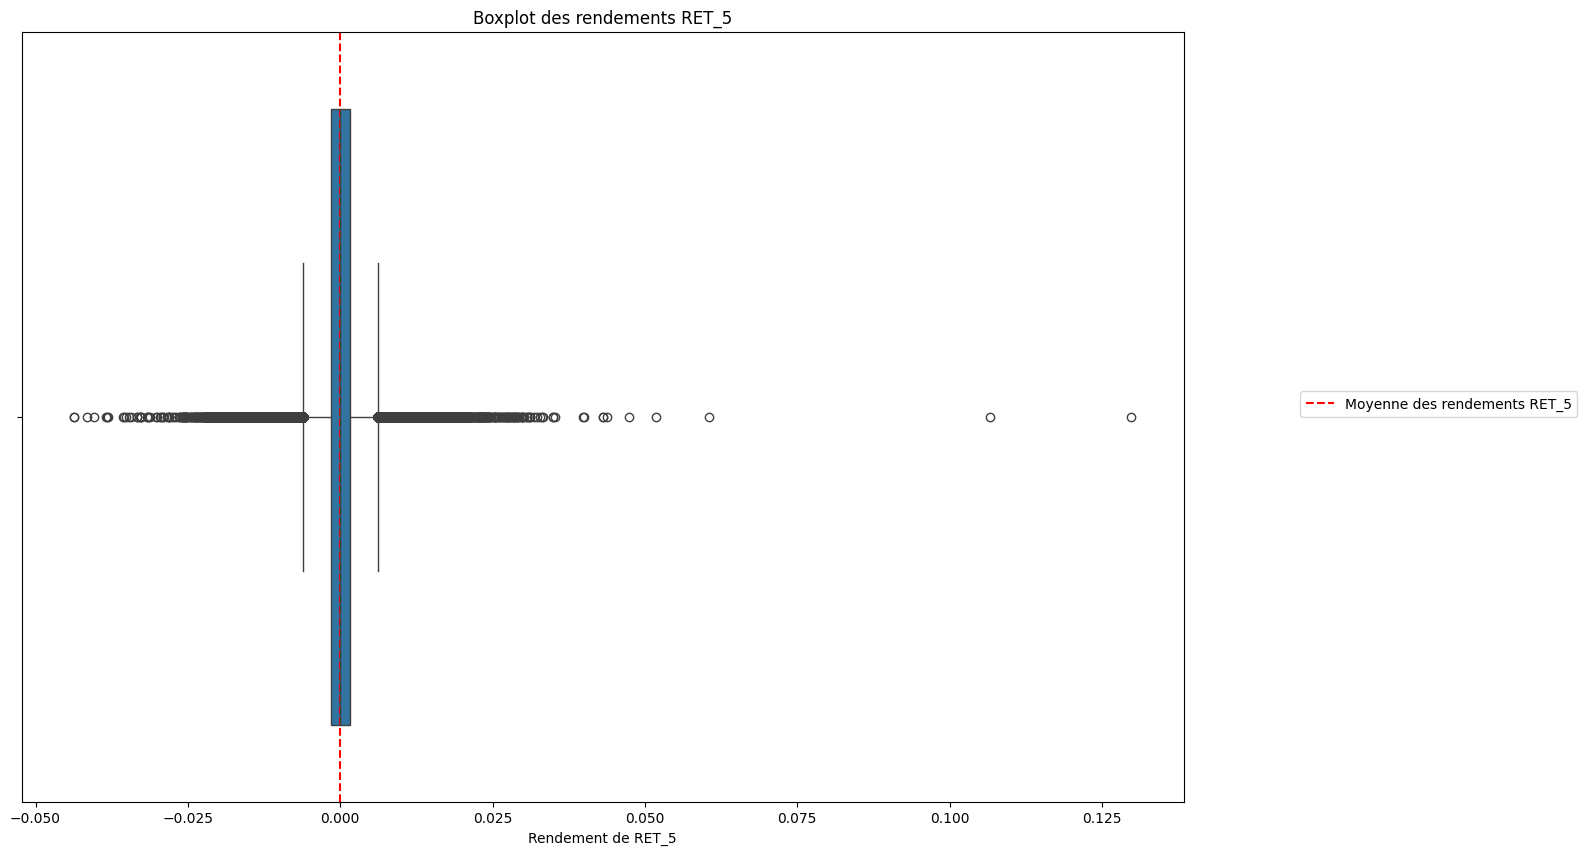

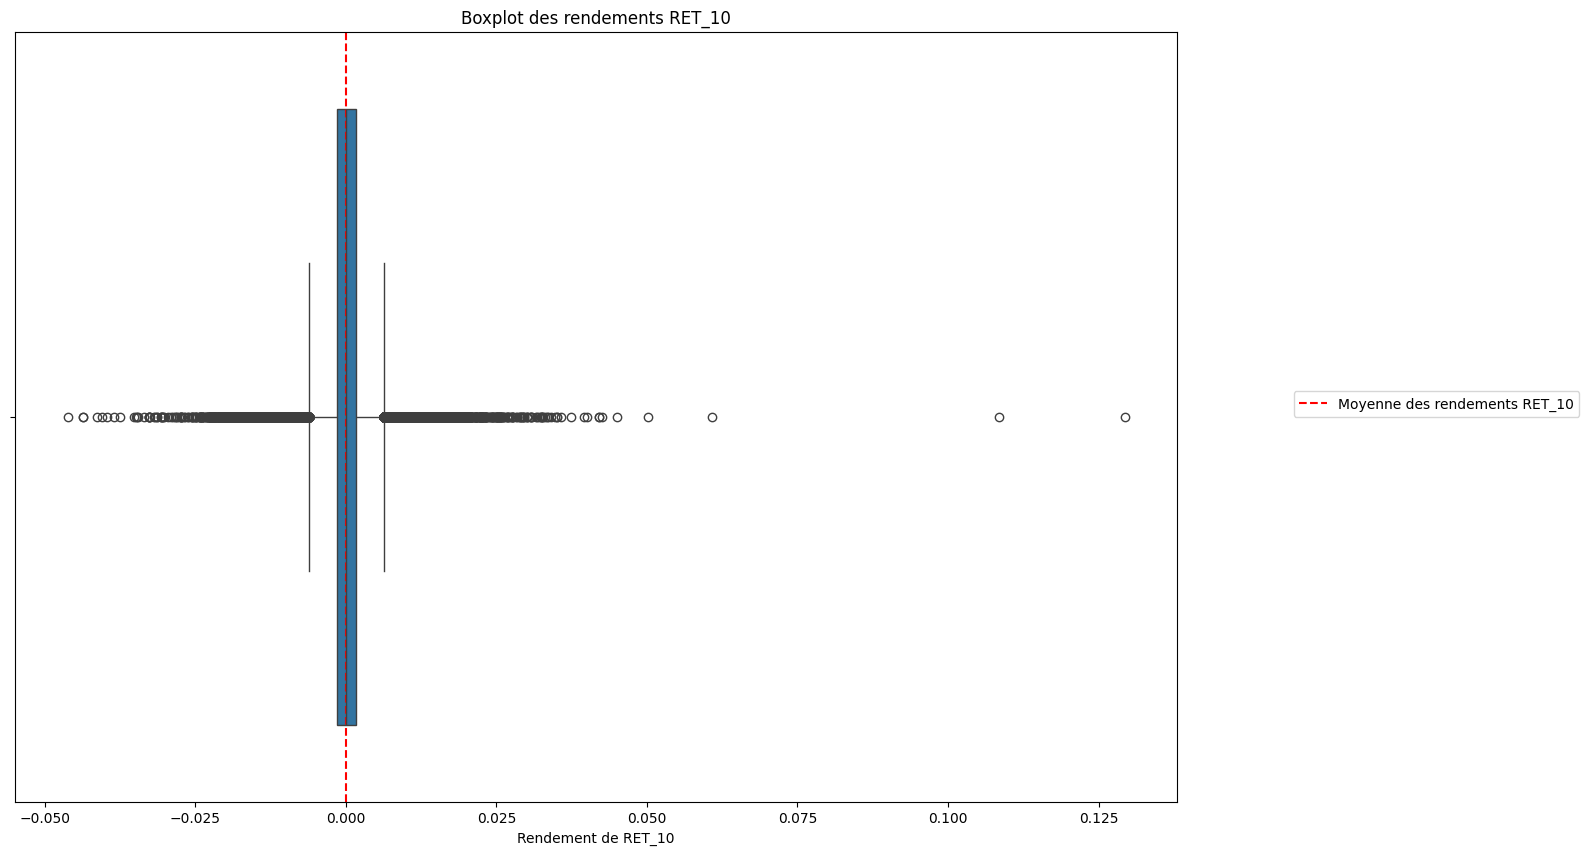

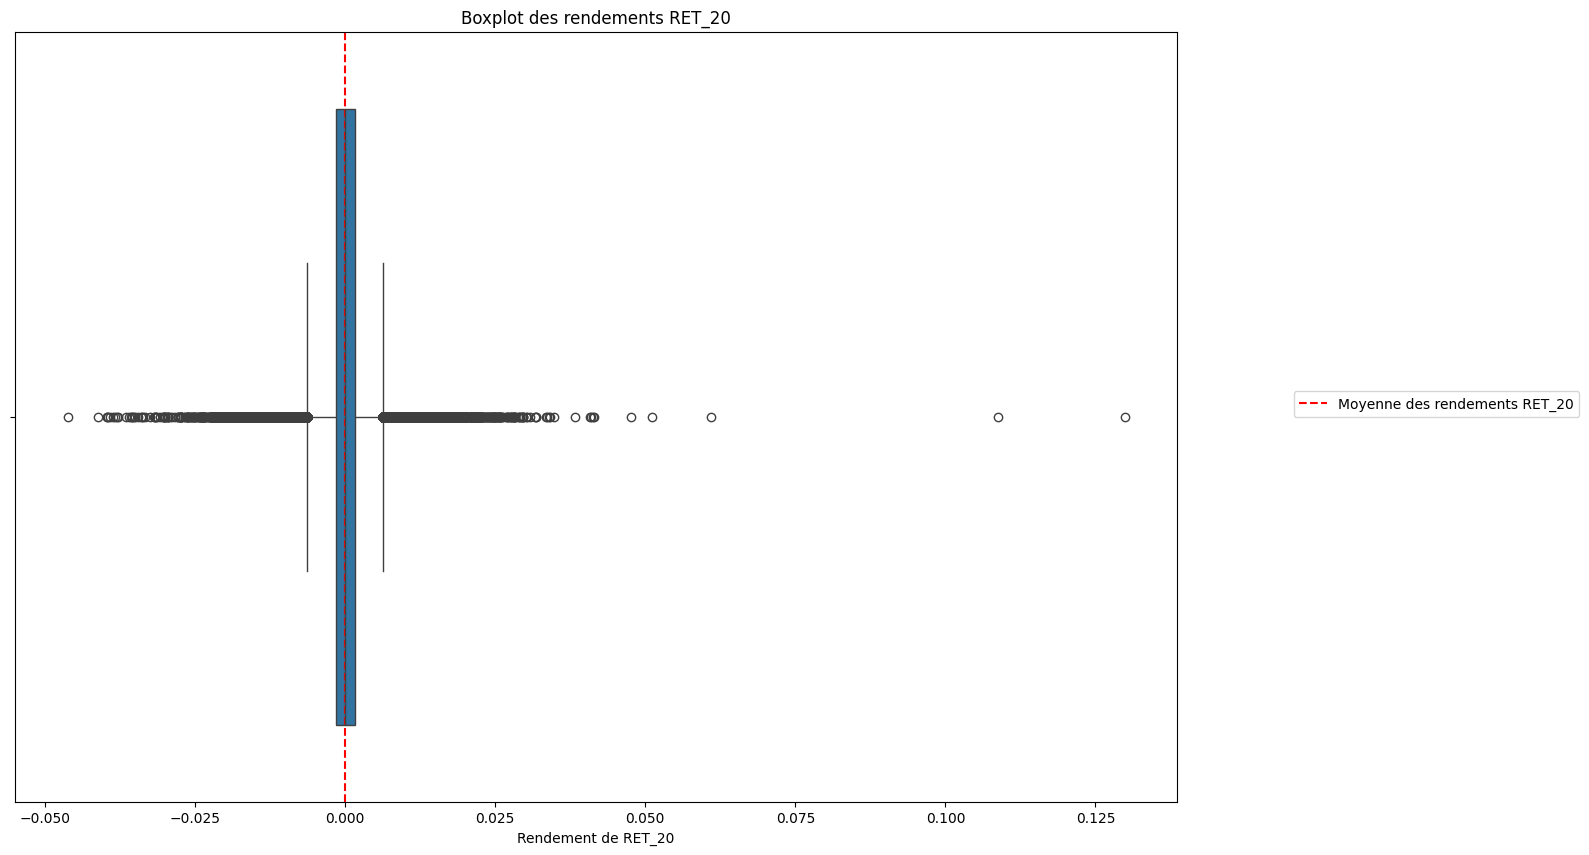

In [34]:
for ret in list_ret:
    plt.figure(figsize=(15,10))
    sns.boxplot(data=X_train,x=ret,fill=True)
    plt.axvline(x=X_train[ret].mean(),label=f"Moyenne des rendements {ret}",ls='--',c='r')
    plt.xlabel(f"Rendement de {ret}")
    plt.title(f"Boxplot des rendements {ret}")
    plt.legend(loc=(1.1,0.5));

Moyenne de chaque RET_i selon la classe future

In [35]:
X_train_ret_target = X_train.merge(y_train,left_on="ROW_ID",right_on="ROW_ID")

In [36]:
X_train_ret_target.columns

Index(['ROW_ID', 'TS', 'ALLOCATION', 'RET_20', 'RET_19', 'RET_18', 'RET_17',
       'RET_16', 'RET_15', 'RET_14', 'RET_13', 'RET_12', 'RET_11', 'RET_10',
       'RET_9', 'RET_8', 'RET_7', 'RET_6', 'RET_5', 'RET_4', 'RET_3', 'RET_2',
       'RET_1', 'SIGNED_VOLUME_20', 'SIGNED_VOLUME_19', 'SIGNED_VOLUME_18',
       'SIGNED_VOLUME_17', 'SIGNED_VOLUME_16', 'SIGNED_VOLUME_15',
       'SIGNED_VOLUME_14', 'SIGNED_VOLUME_13', 'SIGNED_VOLUME_12',
       'SIGNED_VOLUME_11', 'SIGNED_VOLUME_10', 'SIGNED_VOLUME_9',
       'SIGNED_VOLUME_8', 'SIGNED_VOLUME_7', 'SIGNED_VOLUME_6',
       'SIGNED_VOLUME_5', 'SIGNED_VOLUME_4', 'SIGNED_VOLUME_3',
       'SIGNED_VOLUME_2', 'SIGNED_VOLUME_1', 'MEDIAN_DAILY_TURNOVER', 'GROUP',
       'target'],
      dtype='str')

In [37]:
X_train_ret_target["class"] = np.where(X_train_ret_target["target"] > 0,1,0)

In [38]:
ret_target_columns = ['RET_20', 'RET_19', 'RET_18', 'RET_17',
            'RET_16', 'RET_15', 'RET_14', 'RET_13', 'RET_12', 'RET_11', 'RET_10',
            'RET_9', 'RET_8', 'RET_7', 'RET_6', 'RET_5', 'RET_4', 'RET_3', 'RET_2',
            'RET_1','target','class']

In [39]:
X_train_ret_target = X_train_ret_target[ret_target_columns]

In [40]:
ret_columns = ['RET_20', 'RET_19', 'RET_18', 'RET_17',
            'RET_16', 'RET_15', 'RET_14', 'RET_13', 'RET_12', 'RET_11', 'RET_10',
            'RET_9', 'RET_8', 'RET_7', 'RET_6', 'RET_5', 'RET_4', 'RET_3', 'RET_2',
            'RET_1']

In [41]:
mean_1 = X_train_ret_target[X_train_ret_target["class"] == 1].mean(axis=0)[ret_columns]
mean_0 = X_train_ret_target[X_train_ret_target["class"] == 0].mean(axis=0)[ret_columns]

In [42]:
mean_1 = list(mean_1)

In [43]:
mean_0 = list(mean_0)

In [44]:
mean_0[0]

8.475666497255145e-06

In [45]:
mean_ret = pd.DataFrame({
    "ret" : ret_columns,
    "mean_0" : mean_0,
    "mean_1" : mean_1
})

In [46]:
mean_ret

,ret,mean_0,mean_1
0,RET_20,0.000008,3.382619e-05
1,RET_19,0.000008,4.225127e-05
2,RET_18,0.000024,2.984125e-05
3,RET_17,0.000034,1.591413e-05
4,RET_16,0.000006,4.183771e-05
5,RET_15,0.000018,3.595432e-05
6,RET_14,0.000015,3.737461e-05
7,RET_13,0.000018,3.402014e-05
8,RET_12,0.000003,4.472658e-05
9,RET_11,0.000008,3.479273e-05


In [47]:
mean_ret["diff_mean"] = mean_ret["mean_1"] - mean_ret["mean_0"]

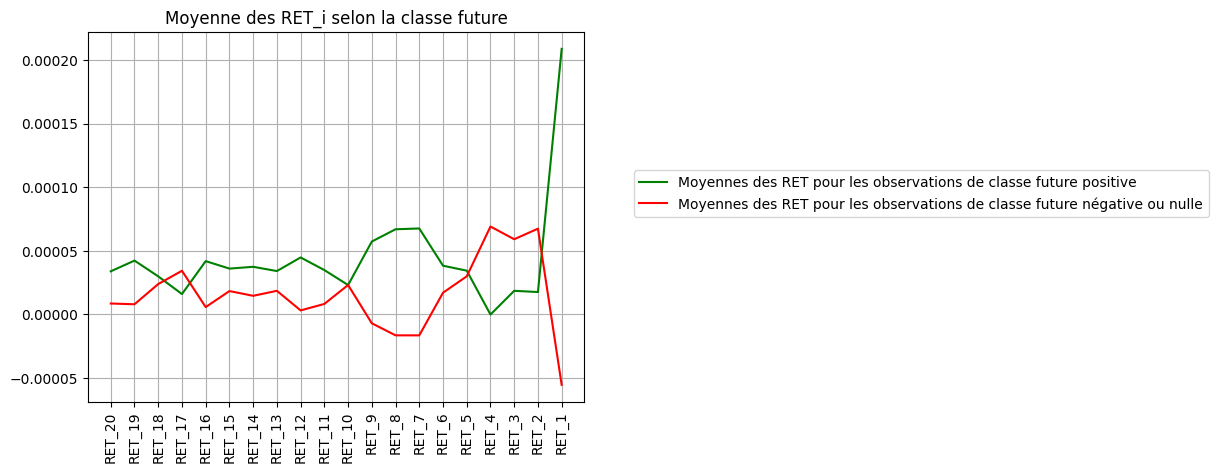

In [48]:
plt.plot(figsize=(15,10))
plt.plot(mean_ret["ret"],mean_ret["mean_1"],label="Moyennes des RET pour les observations de classe future positive",c='g')
plt.plot(mean_ret["ret"],mean_ret["mean_0"],label="Moyennes des RET pour les observations de classe future négative ou nulle",c='r')
# plt.plot(mean_ret["ret"],mean_ret["diff_mean"],label="Différences des moyennes des rendements")
plt.xticks(rotation=90)
plt.grid(True)
plt.title("Moyenne des RET_i selon la classe future")
plt.legend(loc=(1.1,0.5));


Cette figure compare, pour chaque horizon RET_i, la moyenne du rendement passé selon la classe future. La courbe de la classe 1 correspond aux observations dont le rendement futur est positif, tandis que la courbe de la classe 0 correspond aux observations dont le rendement futur est négatif ou nul.

Les deux courbes sont globalement proches, ce qui indique que les rendements passés seuls ne séparent pas fortement les deux classes. Cependant, certains horizons présentent de petits écarts, notamment sur les rendements les plus récents, ce qui peut suggérer un signal faible de momentum ou de reversal à tester avec une validation temporelle.

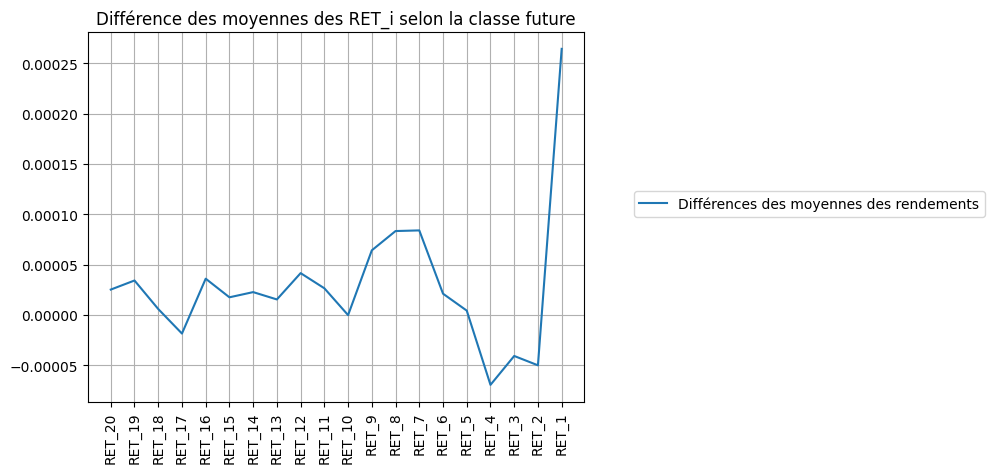

In [49]:
plt.plot(figsize=(15,10))
plt.plot(mean_ret["ret"],mean_ret["diff_mean"],label="Différences des moyennes des rendements")
plt.xticks(rotation=90)
plt.grid(True)
plt.title("Différence des moyennes des RET_i selon la classe future")
plt.legend(loc=(1.1,0.5));


diff_mean mesure l’écart entre la moyenne des RET_i pour les observations de classe future positive et celle des observations de classe future négative ou nulle.

Lorsque diff_mean est positive, cela signifie que les allocations qui finissent positives avaient en moyenne un rendement passé plus élevé. Cela peut suggérer un effet de momentum.

Lorsque diff_mean est négative, cela signifie que les allocations qui finissent positives avaient en moyenne un rendement passé plus faible. Cela peut suggérer un effet de reversal.

reagardons s'il y'a des missing values sur les rte

In [50]:
X_train[ret_columns].isna().sum()

RET_20    58
RET_19    50
RET_18    42
RET_17    34
RET_16    26
RET_15    18
RET_14    13
RET_13     9
RET_12     6
RET_11     4
RET_10     2
RET_9      0
RET_8      0
RET_7      0
RET_6      0
RET_5      0
RET_4      0
RET_3      0
RET_2      0
RET_1      0
dtype: int64

Les rendements les plus anciens ont un peu plus de valeurs manquantes, peut-être parce que certaines allocations n’ont pas assez d’historique complet.

Les valeurs manquantes sur les RET sont très rares, principalement sur les horizons les plus anciens. Elles ne semblent pas être un problème central à ce stade.

## Analyse de SIGNED_VOLUME

Cette section analyse les variables SIGNED_VOLUME_1 à SIGNED_VOLUME_20. Ces variables ne mesurent pas directement la performance passée comme les RET, mais une forme de volume signé agrégé selon les poids de l’allocation. L’objectif est de comprendre leur taux de valeurs manquantes, leur distribution et leur relation éventuelle avec la classe future.

In [4]:
X_train_y_train = X_train.merge(y_train,left_on='ROW_ID',right_on='ROW_ID')
X_train_y_train["class"] = np.where(X_train_y_train["target"] > 0,1,0)

In [52]:
X_train_y_train.columns

Index(['ROW_ID', 'TS', 'ALLOCATION', 'RET_20', 'RET_19', 'RET_18', 'RET_17',
       'RET_16', 'RET_15', 'RET_14', 'RET_13', 'RET_12', 'RET_11', 'RET_10',
       'RET_9', 'RET_8', 'RET_7', 'RET_6', 'RET_5', 'RET_4', 'RET_3', 'RET_2',
       'RET_1', 'SIGNED_VOLUME_20', 'SIGNED_VOLUME_19', 'SIGNED_VOLUME_18',
       'SIGNED_VOLUME_17', 'SIGNED_VOLUME_16', 'SIGNED_VOLUME_15',
       'SIGNED_VOLUME_14', 'SIGNED_VOLUME_13', 'SIGNED_VOLUME_12',
       'SIGNED_VOLUME_11', 'SIGNED_VOLUME_10', 'SIGNED_VOLUME_9',
       'SIGNED_VOLUME_8', 'SIGNED_VOLUME_7', 'SIGNED_VOLUME_6',
       'SIGNED_VOLUME_5', 'SIGNED_VOLUME_4', 'SIGNED_VOLUME_3',
       'SIGNED_VOLUME_2', 'SIGNED_VOLUME_1', 'MEDIAN_DAILY_TURNOVER', 'GROUP',
       'target', 'class'],
      dtype='str')

In [53]:
signed_volume_columns = ['SIGNED_VOLUME_20', 'SIGNED_VOLUME_19', 'SIGNED_VOLUME_18','SIGNED_VOLUME_17', 'SIGNED_VOLUME_16', 
                         'SIGNED_VOLUME_15','SIGNED_VOLUME_14', 'SIGNED_VOLUME_13', 'SIGNED_VOLUME_12','SIGNED_VOLUME_11', 
                         'SIGNED_VOLUME_10', 'SIGNED_VOLUME_9','SIGNED_VOLUME_8', 'SIGNED_VOLUME_7', 'SIGNED_VOLUME_6',
                         'SIGNED_VOLUME_5', 'SIGNED_VOLUME_4', 'SIGNED_VOLUME_3','SIGNED_VOLUME_2', 'SIGNED_VOLUME_1']



In [54]:
X_train_signed_class_volumes = X_train_y_train[signed_volume_columns + ['class']]

Étudier les valeurs manquantes

In [55]:

X_train_signed_class_volumes_1 = X_train_signed_class_volumes[X_train_signed_class_volumes["class"] == 1]

Valeurs manquantes globales des SIGNED_VOLUME

In [56]:
missing_volumes = X_train_y_train[signed_volume_columns].isna().sum()
missing_volumes = pd.DataFrame(missing_volumes)
missing_volumes.columns = ["nb_missing"]
missing_volumes["pct_missing"] = (missing_volumes['nb_missing'] / len(X_train_y_train)) * 100
missing_volumes.sort_values("nb_missing",ascending=False)

,nb_missing,pct_missing
SIGNED_VOLUME_1,387506,73.520366
SIGNED_VOLUME_20,8498,1.612300
SIGNED_VOLUME_19,3002,0.569561
SIGNED_VOLUME_18,859,0.162976
SIGNED_VOLUME_17,58,0.011004
SIGNED_VOLUME_16,50,0.009486
SIGNED_VOLUME_15,42,0.007969
SIGNED_VOLUME_14,34,0.006451
SIGNED_VOLUME_13,26,0.004933
SIGNED_VOLUME_12,18,0.003415


SIGNED_VOLUME_1 est de loin la variable la plus incomplète. Les autres variables de volume sont beaucoup plus complètes.

SIGNED_VOLUME_1 est un cas particulier : environ 73,5 % de ses valeurs sont manquantes. Les autres variables SIGNED_VOLUME sont beaucoup plus complètes, avec des taux de missing généralement très faibles. Cette variable ne doit donc pas être supprimée automatiquement, mais elle devra être traitée avec prudence lors du preprocessing.

In [57]:
X_train_signed_class_volumes_0 = X_train_signed_class_volumes[X_train_signed_class_volumes["class"] == 0]
missing_volumes_0 = X_train_signed_class_volumes_0[signed_volume_columns].isna().sum()
missing_volumes_0 = pd.DataFrame(missing_volumes_0)
missing_volumes_0.columns = ["nb_missing"]
missing_volumes_0["pct_missing"] = (missing_volumes_0['nb_missing'] / len(X_train_signed_class_volumes_0)) * 100
print("Valeurs manquantes des SIGNED_VOLUME pour la classe future 0 :\n")
missing_volumes_0.sort_values("nb_missing",ascending=False)

Valeurs manquantes des SIGNED_VOLUME pour la classe future 0 :



,nb_missing,pct_missing
SIGNED_VOLUME_1,192460,74.094321
SIGNED_VOLUME_20,4242,1.633109
SIGNED_VOLUME_19,1461,0.562464
SIGNED_VOLUME_18,357,0.137440
SIGNED_VOLUME_17,34,0.013090
SIGNED_VOLUME_16,28,0.010780
SIGNED_VOLUME_15,24,0.009240
SIGNED_VOLUME_14,19,0.007315
SIGNED_VOLUME_13,15,0.005775
SIGNED_VOLUME_12,11,0.004235


In [58]:
X_train_signed_class_volumes_1 = X_train_signed_class_volumes[X_train_signed_class_volumes["class"] == 1]
missing_volumes_1 = X_train_signed_class_volumes_1[signed_volume_columns].isna().sum()
missing_volumes_1 = pd.DataFrame(missing_volumes_1)
missing_volumes_1.columns = ["nb_missing"]
missing_volumes_1["pct_missing"] = (missing_volumes_1['nb_missing'] / len(X_train_signed_class_volumes_1)) * 100
print("Valeurs manquantes des SIGNED_VOLUME pour la classe future 1 :\n")
missing_volumes_1.sort_values("nb_missing",ascending=False)

Valeurs manquantes des SIGNED_VOLUME pour la classe future 1 :



,nb_missing,pct_missing
SIGNED_VOLUME_1,195046,72.962671
SIGNED_VOLUME_20,4256,1.592081
SIGNED_VOLUME_19,1541,0.576456
SIGNED_VOLUME_18,502,0.187788
SIGNED_VOLUME_17,24,0.008978
SIGNED_VOLUME_16,22,0.008230
SIGNED_VOLUME_15,18,0.006733
SIGNED_VOLUME_14,15,0.005611
SIGNED_VOLUME_13,11,0.004115
SIGNED_VOLUME_12,7,0.002619


SIGNED_VOLUME_1 classe 0 : environ 74,09 %

SIGNED_VOLUME_1 classe 1 : environ 72,96 %

Les taux de missing de SIGNED_VOLUME_1 sont élevés dans les deux classes : environ 74,1 % pour la classe future 0 et 73,0 % pour la classe future 1. L’écart entre les deux classes reste faible, ce qui suggère que le missing de cette variable n’est pas fortement discriminant à lui seul. Il pourra néanmoins être utile de tester plus tard un indicateur de missing en feature engineering.

**Traçons les distributions de quelques volumes signés**

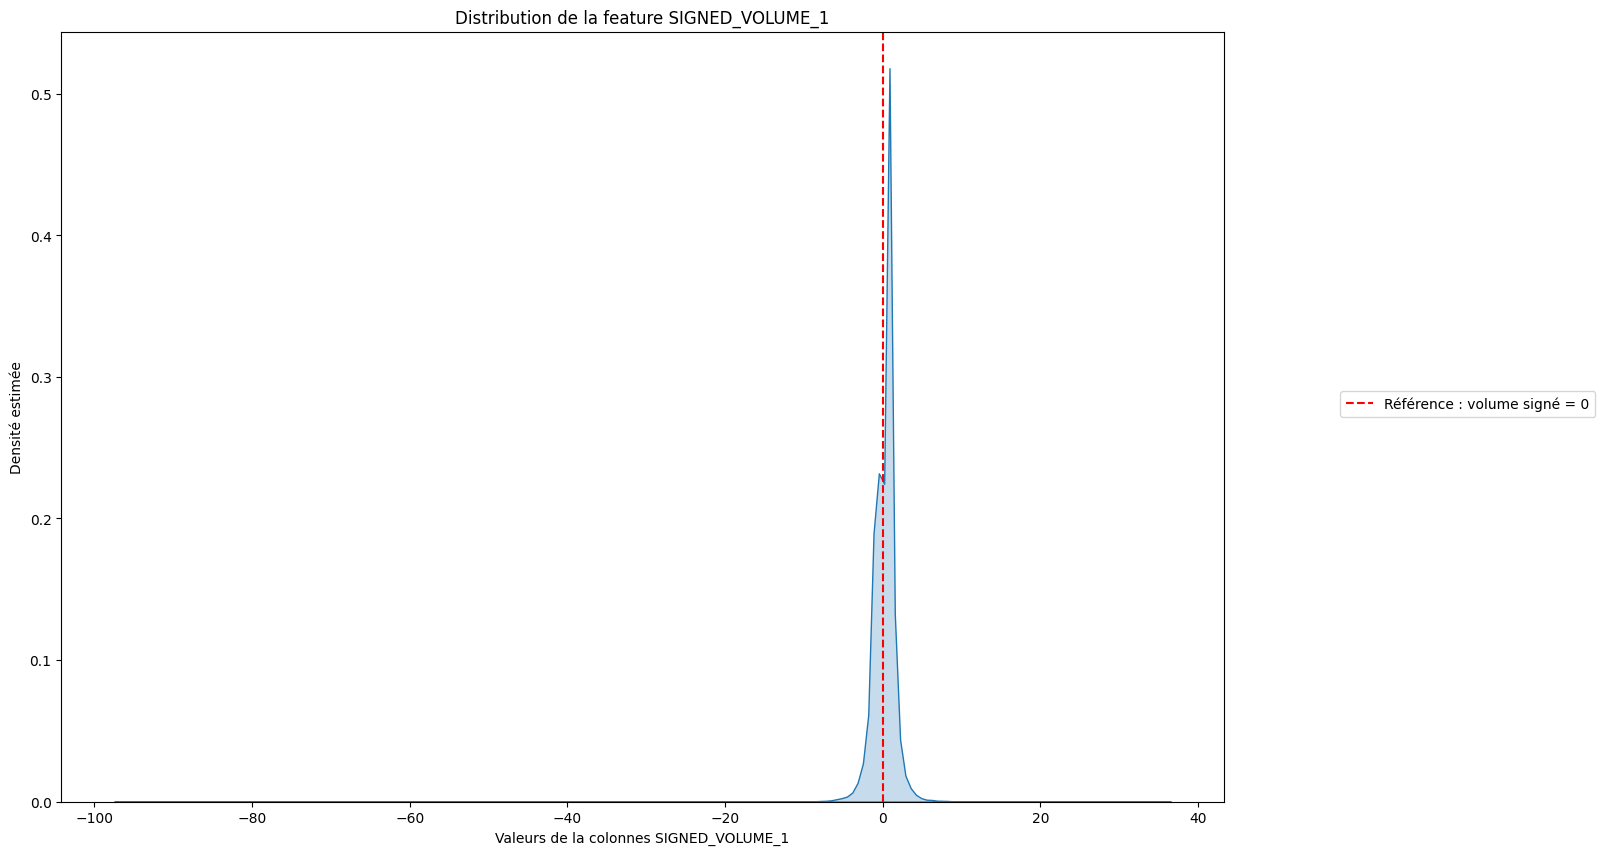

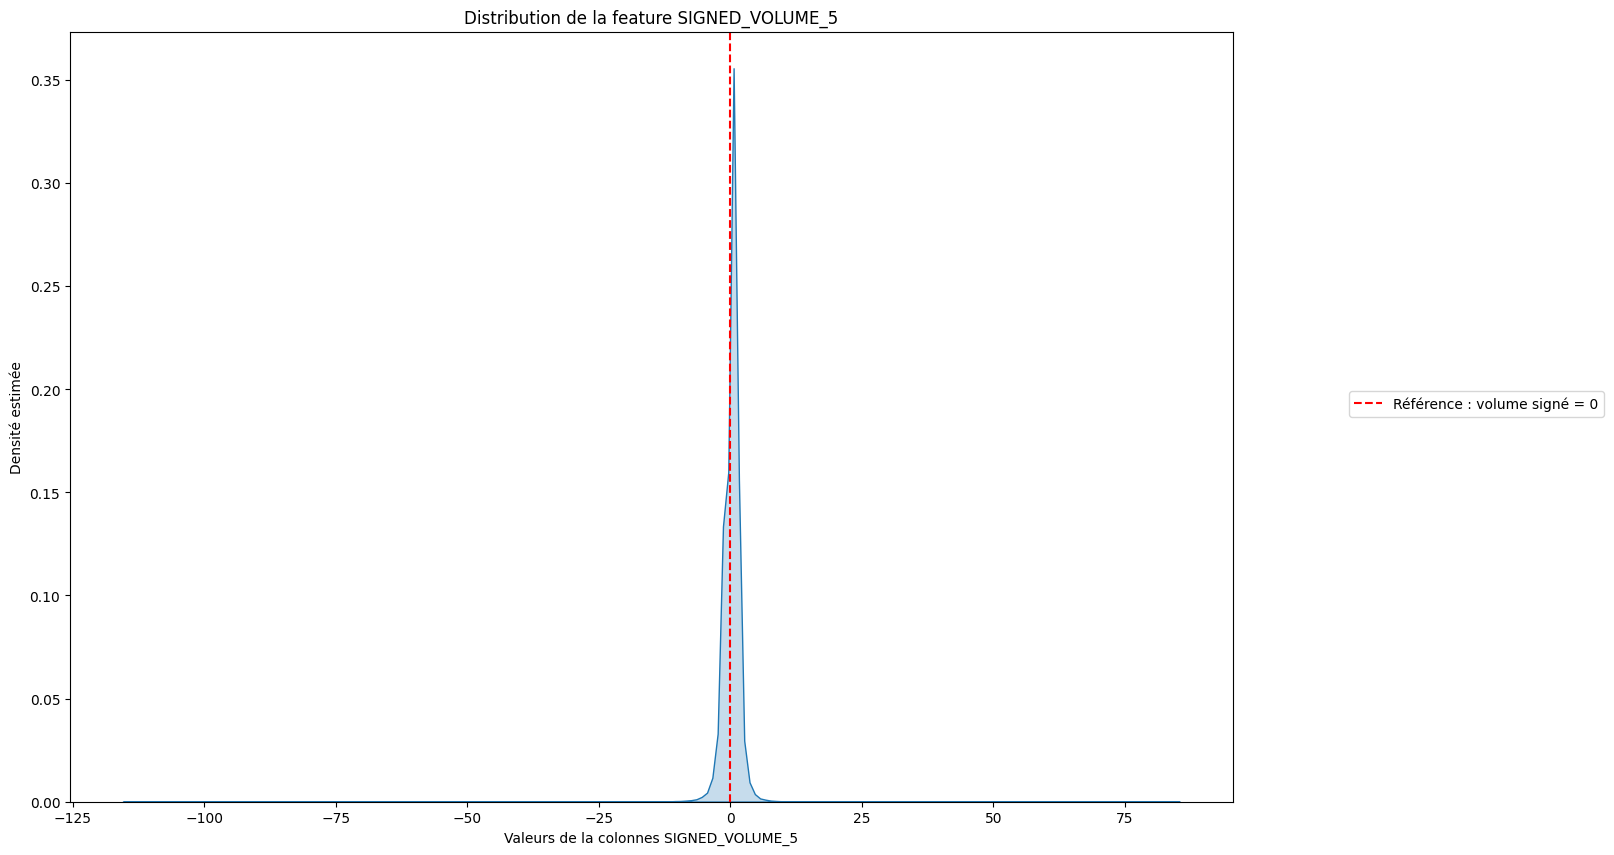

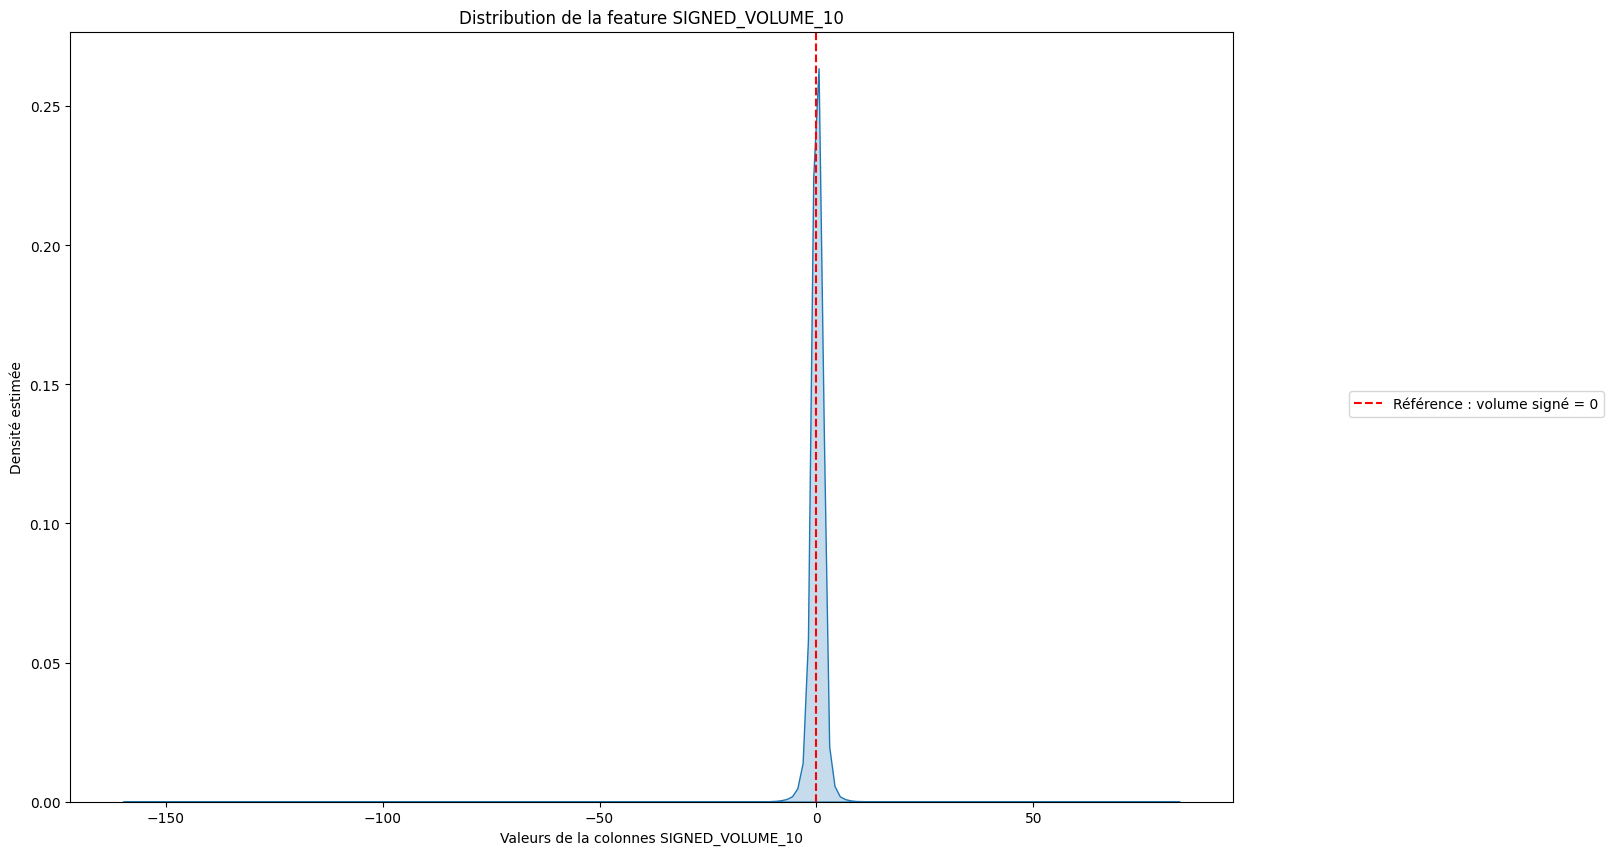

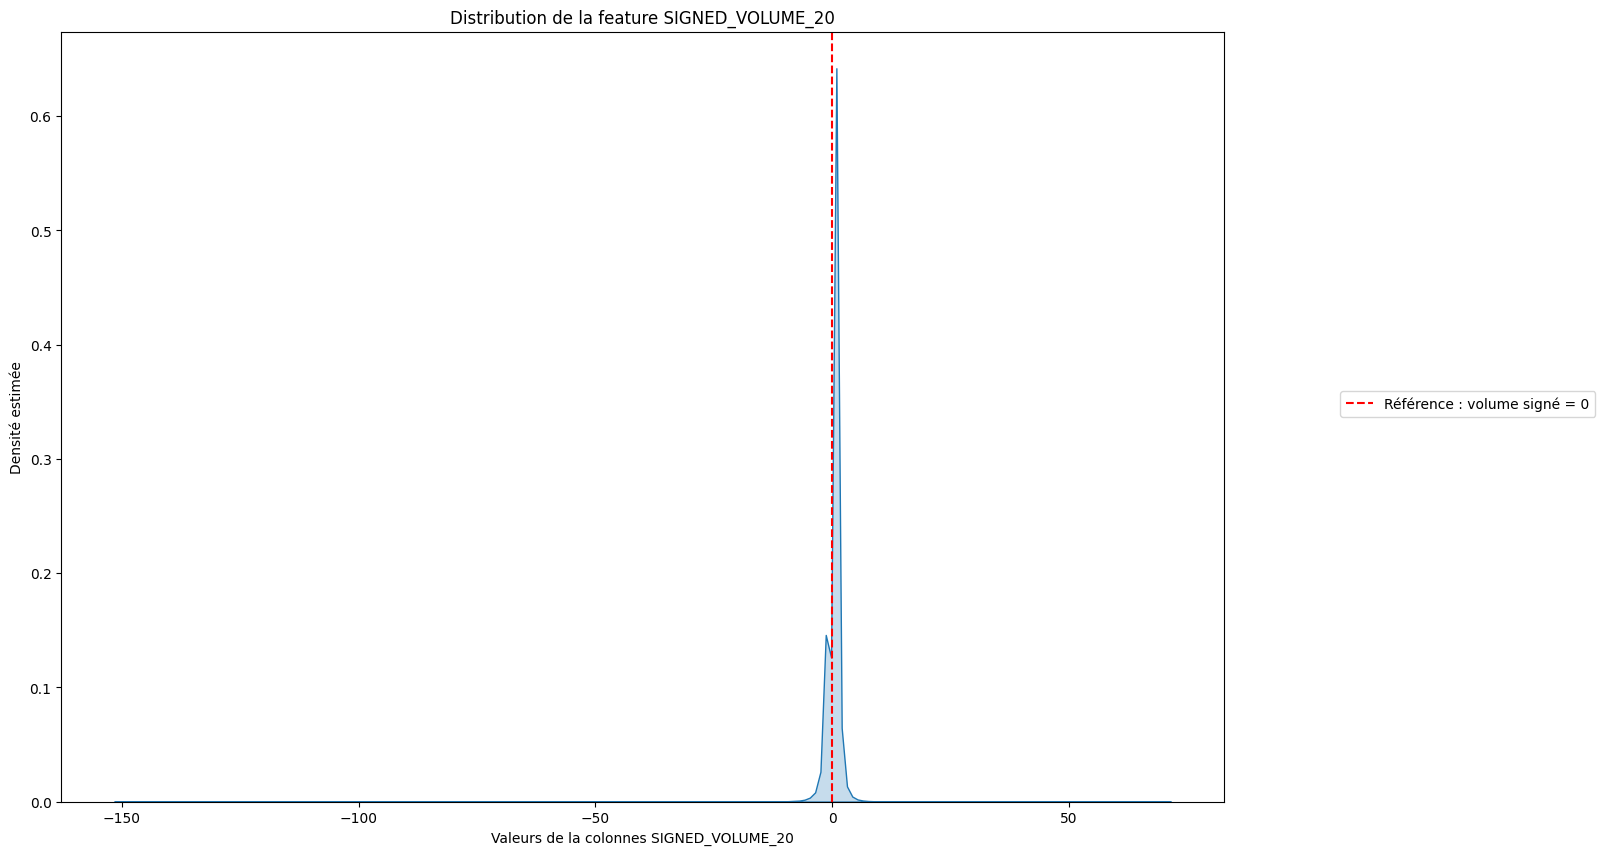

In [59]:
iterations = [1,5,10,20] 
for i in iterations:
    plt.figure(figsize=(15,10))
    sns.kdeplot(data=X_train,x=f"SIGNED_VOLUME_{i}",fill=True)
    plt.axvline(x=0,ls="--",c='r',label=f"Référence : volume signé = 0")
    plt.xlabel(f"Valeurs de la colonnes SIGNED_VOLUME_{i}")
    plt.ylabel("Densité estimée")
    plt.title(f"Distribution de la feature SIGNED_VOLUME_{i}")
    plt.legend(loc=(1.1,0.5));

Les distributions des SIGNED_VOLUME sont plus difficiles à lire que celles des RET, car elles peuvent être asymétriques, contenir des valeurs extrêmes et présenter des valeurs manquantes importantes selon l’horizon. SIGNED_VOLUME_1 doit être interprété avec prudence car il est observé seulement sur une partie des lignes. Le signe du volume indique une exposition agrégée long/short aux volumes de marché, mais ne permet pas à lui seul de conclure sur le signe de la target future.

In [60]:
X_train[signed_volume_columns].describe()

,SIGNED_VOLUME_20,SIGNED_VOLUME_19,SIGNED_VOLUME_18,SIGNED_VOLUME_17,SIGNED_VOLUME_16,SIGNED_VOLUME_15,SIGNED_VOLUME_14,SIGNED_VOLUME_13,SIGNED_VOLUME_12,SIGNED_VOLUME_11,SIGNED_VOLUME_10,SIGNED_VOLUME_9,SIGNED_VOLUME_8,SIGNED_VOLUME_7,SIGNED_VOLUME_6,SIGNED_VOLUME_5,SIGNED_VOLUME_4,SIGNED_VOLUME_3,SIGNED_VOLUME_2,SIGNED_VOLUME_1
count,518575.000000,524071.000000,526214.000000,527015.000000,527023.000000,527031.000000,527039.000000,527047.000000,527055.000000,527060.000000,527064.000000,527067.000000,527069.000000,527071.000000,527073.000000,527073.000000,527073.000000,527073.000000,527073.000000,139567.000000
mean,0.247504,0.250505,0.252230,0.253134,0.255166,0.255774,0.257338,0.258577,0.258836,0.259446,0.259714,0.260023,0.260059,0.259768,0.259258,0.258893,0.258606,0.258928,0.259200,0.195340
std,1.628739,1.639324,1.631489,1.639422,1.623063,1.623572,1.583553,1.576420,1.599700,1.595813,1.591820,1.590091,1.583801,1.583175,1.584035,1.586910,1.585926,1.586087,1.583925,1.495215
min,-151.255330,-198.833900,-200.051120,-204.219060,-200.164250,-188.672500,-110.555040,-121.861480,-208.479080,-172.775390,-159.571580,-146.246230,-116.792020,-116.792020,-115.097120,-115.097120,-115.097120,-115.228750,-115.228750,-97.084880
25%,-0.793455,-0.783864,-0.775915,-0.770371,-0.764016,-0.759717,-0.756025,-0.752211,-0.749223,-0.745649,-0.743137,-0.741001,-0.740970,-0.741497,-0.742433,-0.742877,-0.743152,-0.743793,-0.744331,-0.658435
50%,0.673275,0.668199,0.663144,0.658543,0.654934,0.650987,0.647672,0.643968,0.640873,0.637518,0.635481,0.634476,0.633392,0.633209,0.633021,0.633397,0.634218,0.634884,0.635748,0.470273
75%,1.062713,1.068803,1.072402,1.076246,1.078709,1.082619,1.085568,1.087881,1.090110,1.092272,1.094094,1.096244,1.097264,1.097693,1.097731,1.098027,1.097931,1.098621,1.098757,0.966014
max,71.193100,85.870010,64.371870,65.502210,70.387970,125.028400,111.365814,66.236210,82.982900,81.524340,83.413760,79.264060,80.194916,81.463974,80.126700,85.056590,84.008095,84.008095,78.656590,36.160908


Les SIGNED_VOLUME ont des moyennes proches mais des valeurs extrêmes importantes. Les min/max sont très éloignés des quartiles, ce qui suggère la présence d’outliers. La médiane et les quartiles sont donc plus fiables que la moyenne seule pour comprendre la distribution typique.

## Analyse de MEDIAN_DAILY_TURNOVER

MEDIAN_DAILY_TURNOVER mesure le niveau typique de rotation de l’allocation. Contrairement aux RET, cette variable ne mesure pas directement une performance passée, mais plutôt le degré d’activité ou de rebalancement de l’allocation. Elle peut être liée à la stabilité de la stratégie, aux coûts potentiels de transaction ou au style d’allocation. L’objectif est d’analyser sa distribution, ses valeurs manquantes et son éventuelle relation avec la classe future.

In [61]:
X_train.describe()["MEDIAN_DAILY_TURNOVER"]

count    5.234350e+05
mean     9.094372e-02
std      2.364887e-01
min      6.917210e-16
25%      1.892675e-03
50%      1.593524e-02
75%      4.449061e-02
max      1.560090e+00
Name: MEDIAN_DAILY_TURNOVER, dtype: float64

La moyenne est beaucoup plus grande que la médiane.

Ça suggère que la distribution est très asymétrique à droite : beaucoup d’allocations ont un turnover faible, mais quelques allocations ont un turnover très élevé, ce qui tire la moyenne vers le haut.

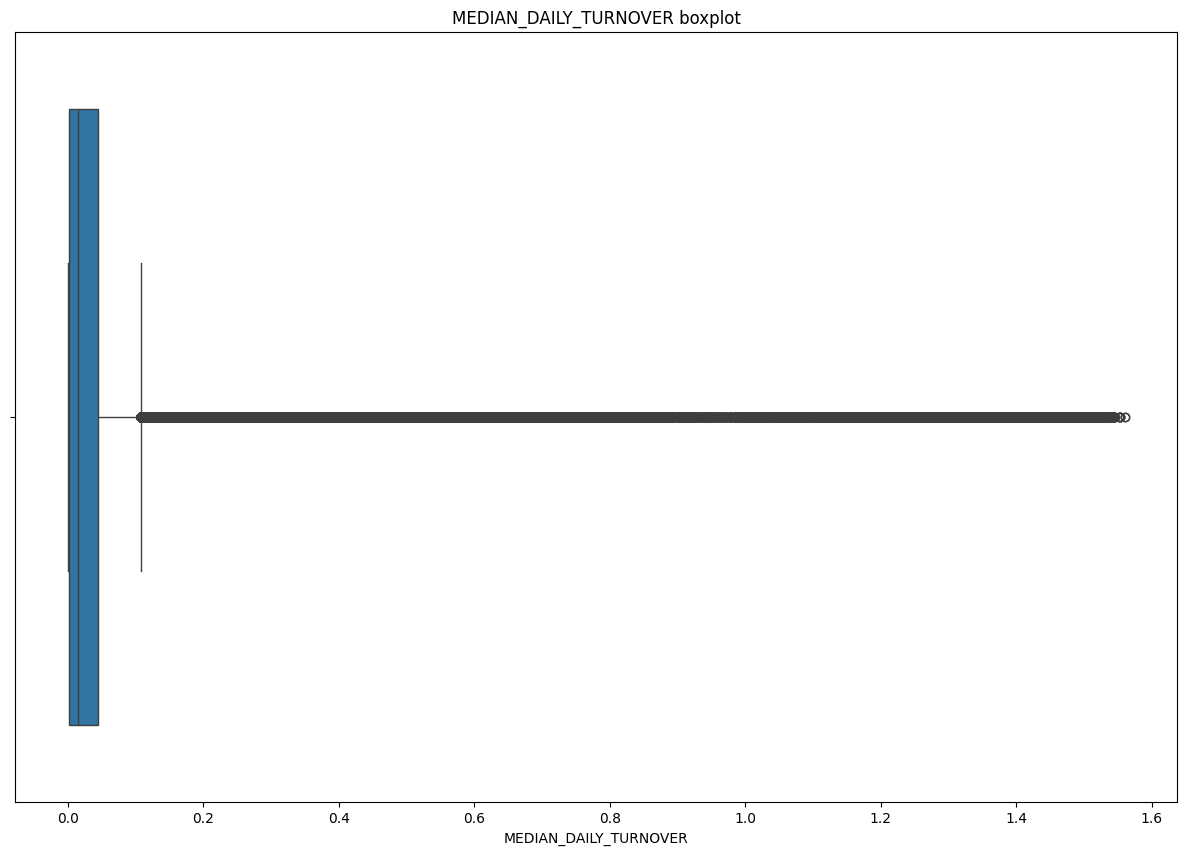

In [62]:
plt.figure(figsize=(15,10))
sns.boxplot(data=X_train,x="MEDIAN_DAILY_TURNOVER")
plt.xlabel("MEDIAN_DAILY_TURNOVER")
plt.title("MEDIAN_DAILY_TURNOVER boxplot");

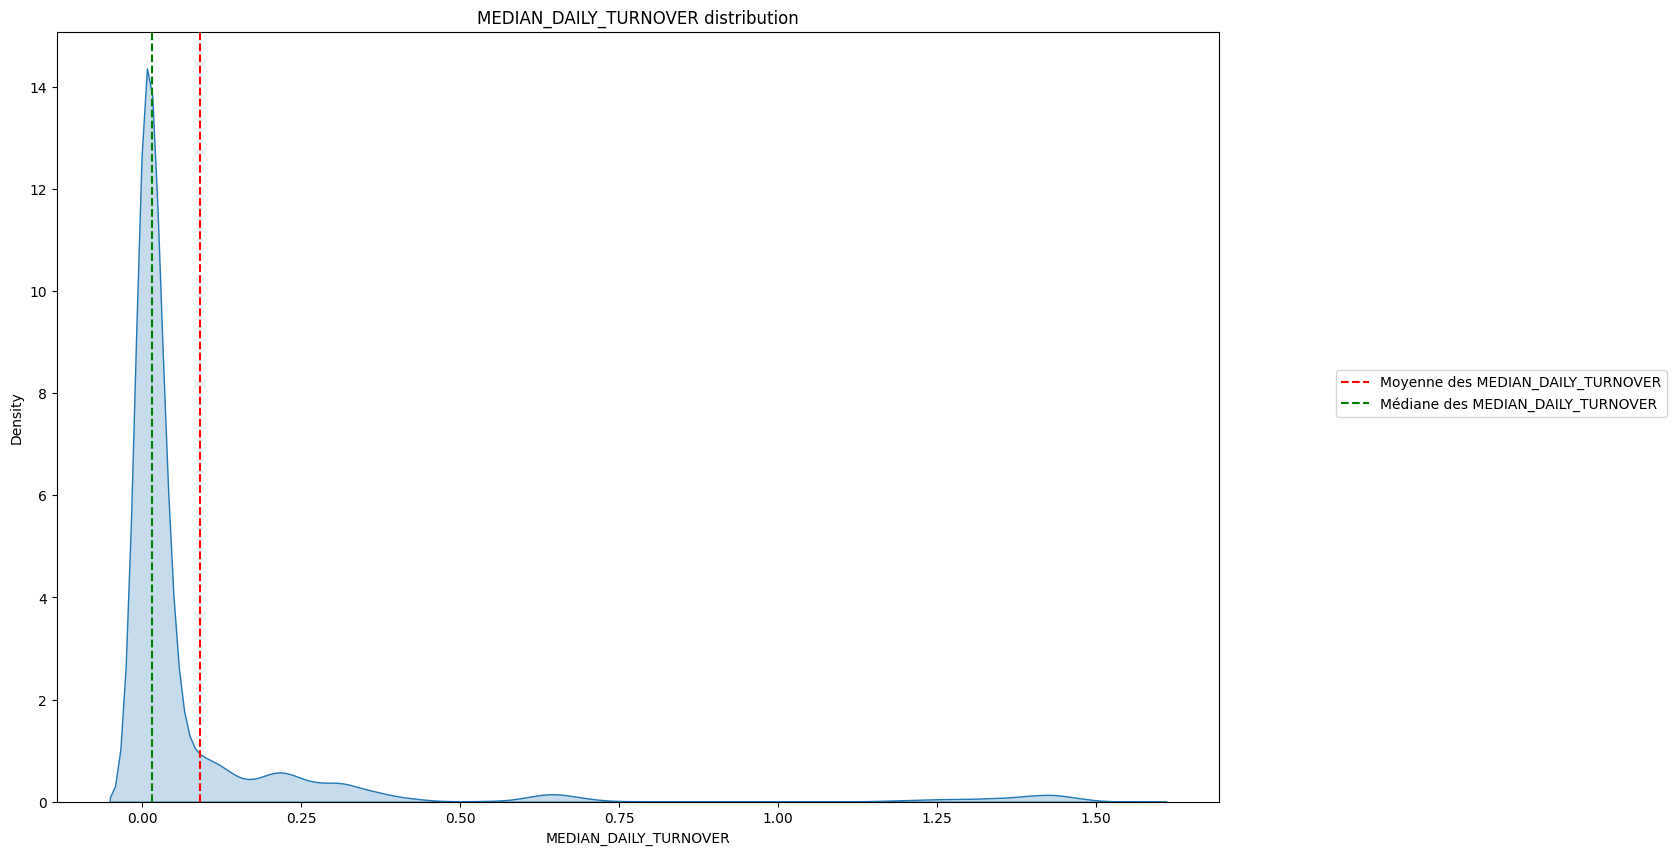

In [63]:
plt.figure(figsize=(15,10))
sns.kdeplot(data=X_train,x="MEDIAN_DAILY_TURNOVER",fill=True)
plt.axvline(x=X_train["MEDIAN_DAILY_TURNOVER"].mean(),ls='--',c='r',label='Moyenne des MEDIAN_DAILY_TURNOVER')
plt.axvline(x=X_train["MEDIAN_DAILY_TURNOVER"].median(),ls='--',c='g',label='Médiane des MEDIAN_DAILY_TURNOVER')
plt.xlabel("MEDIAN_DAILY_TURNOVER")
plt.title("MEDIAN_DAILY_TURNOVER distribution")
plt.legend(loc=(1.1,0.5));

La moyenne est fortement influencée par les valeurs extrêmes. La médiane est plus représentative du turnover typique.

In [64]:
nb_nan = X_train["MEDIAN_DAILY_TURNOVER"].isna().sum()
pct_nan = (nb_nan / len(X_train)) * 100

In [65]:
print(f"Le pourcentage de valeur manquante de la colonne MEDIAN_DAILY_TURNOVER est {pct_nan:.2f}%")

Le pourcentage de valeur manquante de la colonne MEDIAN_DAILY_TURNOVER est 0.69%


In [66]:
X_train_1 = X_train_y_train[X_train_y_train["class"] == 1]
X_train_0 = X_train_y_train[X_train_y_train["class"] == 0]

In [67]:
nb_nan_1 = X_train_1["MEDIAN_DAILY_TURNOVER"].isna().sum()
pct_nan_1 = (nb_nan_1 / len(X_train_1)) * 100
print(f"Le pourcentage de valeur manquante de la colonne MEDIAN_DAILY_TURNOVER dont la classe future est 1 est {pct_nan_1:.2f}%")

Le pourcentage de valeur manquante de la colonne MEDIAN_DAILY_TURNOVER dont la classe future est 1 est 0.68%


In [68]:
nb_nan_0 = X_train_0["MEDIAN_DAILY_TURNOVER"].isna().sum()
pct_nan_0 = (nb_nan_0 / len(X_train_0)) * 100
print(f"Le pourcentage de valeur manquante de la colonne MEDIAN_DAILY_TURNOVER dont la classe future est 0 est {pct_nan_0:.2f}%")

Le pourcentage de valeur manquante de la colonne MEDIAN_DAILY_TURNOVER dont la classe future est 0 est 0.70%


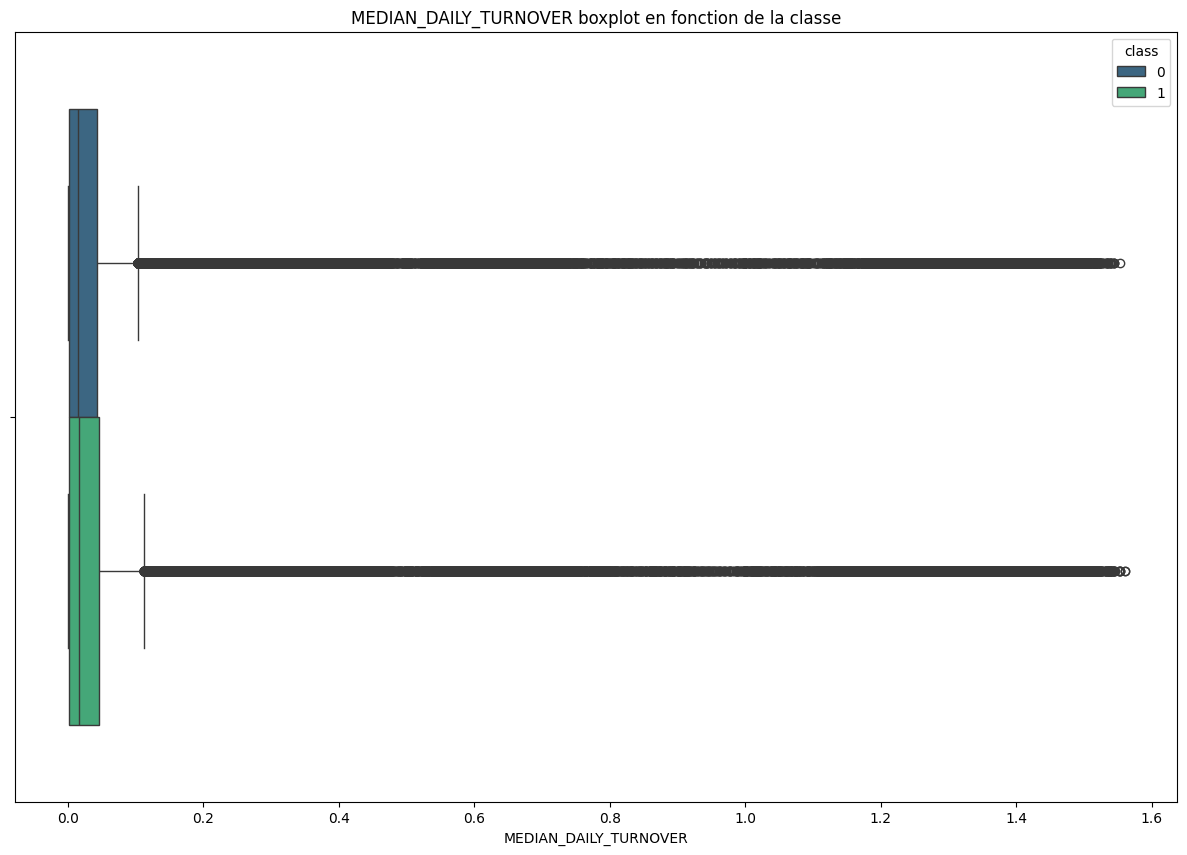

In [69]:
plt.figure(figsize=(15,10))
sns.boxplot(data=X_train_y_train,x="MEDIAN_DAILY_TURNOVER",hue="class",palette="viridis")
plt.xlabel("MEDIAN_DAILY_TURNOVER")
plt.title("MEDIAN_DAILY_TURNOVER boxplot en fonction de la classe");

## Analyse de Allocation et Group

Vérifions dans un premier temps si les allocations du test existent déjà dans le train

Si beaucoup d’allocations du test sont nouvelles, alors un encodage basé sur l’historique de ALLOCATION généralisera mal.

In [70]:
X_train["ALLOCATION"].unique()

<StringArray>
['ALLOCATION_01', 'ALLOCATION_02', 'ALLOCATION_03', 'ALLOCATION_04',
 'ALLOCATION_05', 'ALLOCATION_06', 'ALLOCATION_07', 'ALLOCATION_08',
 'ALLOCATION_09', 'ALLOCATION_10',
 ...
 'ALLOCATION_92', 'ALLOCATION_93', 'ALLOCATION_94', 'ALLOCATION_95',
 'ALLOCATION_96', 'ALLOCATION_97', 'ALLOCATION_98', 'ALLOCATION_99',
 'ALLOCATION_14', 'ALLOCATION_46']
Length: 278, dtype: str

In [71]:
print(f"Le nombre d'allocations uniques dans le train est {X_train["ALLOCATION"].nunique()}")
print(f"Le nombre d'allocations uniques dans le test est {X_test["ALLOCATION"].nunique()}")
print(f"Le nombre d'allocation présentent dans X_train et pas dasn X_test est {len(set(X_train["ALLOCATION"].unique()) - set(X_test["ALLOCATION"].unique()))}")
print(f"Le nombre d'allocation présentent dans X_test et pas dasn X_train est {len(set(X_test["ALLOCATION"].unique()) - set(X_train["ALLOCATION"].unique()))}")

Le nombre d'allocations uniques dans le train est 278
Le nombre d'allocations uniques dans le test est 278
Le nombre d'allocation présentent dans X_train et pas dasn X_test est 0
Le nombre d'allocation présentent dans X_test et pas dasn X_train est 0


Toutes les allocations présentes dans le test sont déjà présentes dans le train, et inversement. Cela signifie que le modèle ne rencontrera pas de nouvelles catégories ALLOCATION inconnues dans le test.

In [73]:
print(f"Le nombre de groupes uniques dans le train est {X_train["GROUP"].nunique()}")
print(f"Le nombre de groupes uniques dans le test est {X_test["GROUP"].nunique()}")
print(f"Le nombre de groupes présentent dans X_train et pas dasn X_test est {len(set(X_train["GROUP"].unique()) - set(X_test["GROUP"].unique()))}")
print(f"Le nombre de groupes présentent dans X_test et pas dasn X_train est {len(set(X_test["GROUP"].unique()) - set(X_train["GROUP"].unique()))}")

Le nombre de groupes uniques dans le train est 4
Le nombre de groupes uniques dans le test est 4
Le nombre de groupes présentent dans X_train et pas dasn X_test est 0
Le nombre de groupes présentent dans X_test et pas dasn X_train est 0


Trouvons le nombre d'observations par groupe dans le train et dans le test

In [81]:
X_train["GROUP"].value_counts()

GROUP
3    168913
2    134928
4    123062
1    100170
Name: count, dtype: int64

In [82]:
X_test["GROUP"].value_counts()

GROUP
2    8050
1    7980
3    7980
4    7860
Name: count, dtype: int64

Trouvons les 10 allocations les plus fréquentes dans le train et dans le test

In [84]:
X_train["ALLOCATION"].value_counts()[:10]

ALLOCATION
ALLOCATION_09     2439
ALLOCATION_101    2439
ALLOCATION_103    2439
ALLOCATION_104    2439
ALLOCATION_107    2439
ALLOCATION_110    2439
ALLOCATION_112    2439
ALLOCATION_115    2439
ALLOCATION_116    2439
ALLOCATION_118    2439
Name: count, dtype: int64

In [83]:
X_test["ALLOCATION"].value_counts()[:10]

ALLOCATION
ALLOCATION_02     116
ALLOCATION_05     116
ALLOCATION_07     116
ALLOCATION_105    116
ALLOCATION_108    116
ALLOCATION_111    116
ALLOCATION_113    116
ALLOCATION_12     116
ALLOCATION_120    116
ALLOCATION_121    116
Name: count, dtype: int64

In [9]:
allocations_target_1 = X_train_y_train[X_train_y_train["class"] == 1][["ALLOCATION","class"]]
allocations_target_0 = X_train_y_train[X_train_y_train["class"] == 0][["ALLOCATION","class"]]
allocations_class = X_train_y_train[["ALLOCATION","class"]]
allocations_class["class_0"] = np.where(allocations_class["class"] == 1,0,1)

trouvons la proportions de classe positive et négative par allocation

In [13]:
allocations_class.groupby("ALLOCATION").sum().sort_values("class",ascending=False).head(10)

,class,class_0
ALLOCATION,,
ALLOCATION_152,1607,832
ALLOCATION_118,1425,1014
ALLOCATION_63,1327,1112
ALLOCATION_127,1321,1118
ALLOCATION_112,1314,1125
ALLOCATION_259,1300,1139
ALLOCATION_255,1293,1146
ALLOCATION_148,1288,1151
ALLOCATION_97,1284,1155


cette liste nous donne le top 10 des allocations avec le plus d'observations qui ont des classes positives

In [20]:
allocations_class = allocations_class.groupby("ALLOCATION").sum().sort_values("class",ascending=False).head(10)
allocations_class["pct_of_class_1"] = ( allocations_class["class"] / (allocations_class["class"] + allocations_class["class_0"]) ) * 100
allocations_class.head(10)

,class,class_0,pct_of_class_1
ALLOCATION,,,
ALLOCATION_152,1607,832,65.887659
ALLOCATION_118,1425,1014,58.425584
ALLOCATION_63,1327,1112,54.407544
ALLOCATION_127,1321,1118,54.161542
ALLOCATION_112,1314,1125,53.874539
ALLOCATION_259,1300,1139,53.300533
ALLOCATION_255,1293,1146,53.013530
ALLOCATION_148,1288,1151,52.808528
ALLOCATION_97,1284,1155,52.644526


Parmi les allocations ayant le plus grand nombre d’observations positives, voici leur proportion positive.